
<tr>
    <td><h1 style="text-align: left; font-size:300%;">
        ML2026 - Homework
    </h1></td>
    <div style="text-align: right">
    <b> Machine Learning 2026</b> <br>
    <td width="100px"> 
        
</tr>


### Packages

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Task 1
_Perform preliminary analysis of the data. For instance, but not limited to, visualizing samples, identifying if features are correlated, determining which are most correlated with the target class, and inspecting the distribution of samples among classes. We want to recover the data for the Exit Rate variable. Train a regressor to predict this variable’s values given the remaining variables. Compare different regression algorithms for this task, and perform feature selection. Since this feature is also missing in the test set, use only the training data for this step and use robust evaluation techniques to compare algorithms._

**1.1 Preliminary Analysis of the data and Explorative analysis**
 - Descriptive Analysis
    - Continuous Variables
    - Categorical variables

**1.2 ``ExitRates`` Variable**
- Encoding
- Regressors for ExitRates


---
---

## 1.1 Preliminary analysis of the data

We first inspected the dataset structure, class balance, and correlations. Exit Rate was found to be missing in a significant portion of both the training and test sets. We restricted our missingness analysis to the training set only, to avoid any use of test-set information ahead of final evaluation.

### Data preprocessing

In [3]:
data = pd.read_csv("data/online_shoppers_intention.csv")
train_data = pd.read_csv("data/training_set_online_shoppers_intention.csv")
test_data = pd.read_csv("data/test_set_online_shoppers_intention.csv")

In [4]:
data.head()
train_data.head()
test_data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,3496,0,0.000000,0,0.0,5,19.000000,0.000000,0.080000,0.000000,0.6,May,2,2,1,3,Returning_Visitor,False,False
1,9415,5,158.700000,0,0.0,51,1364.266667,0.007692,0.011987,0.000000,0.0,Nov,3,2,3,2,Returning_Visitor,True,False
2,9419,7,87.916667,1,0.0,46,1621.025379,0.004082,0.020544,6.023523,0.0,Dec,1,1,3,2,Returning_Visitor,False,False
3,3837,1,4.000000,0,0.0,37,1296.942857,0.013889,NaN,0.000000,0.8,May,2,2,4,2,Returning_Visitor,False,False
4,7305,2,132.400000,0,0.0,11,296.300000,0.000000,NaN,0.000000,0.0,Sep,2,4,3,2,New_Visitor,False,False


,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0,0.0,0,0.0,1,0.000000,0.200000,NaN,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,3,0,0.0,0,0.0,2,2.666667,0.050000,NaN,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
2,5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
3,12,0,0.0,0,0.0,7,280.500000,0.000000,0.028571,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
4,14,0,0.0,0,0.0,2,68.000000,0.000000,NaN,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False


Since I want to remove unnamed column (ID perhaps):

In [5]:
train_data.drop(["Unnamed: 0"], inplace = True, axis = 1)
test_data.drop(["Unnamed: 0"], inplace = True, axis = 1)

In [6]:
train_data.head()
test_data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.000000,0,0.0,5,19.000000,0.000000,0.080000,0.000000,0.6,May,2,2,1,3,Returning_Visitor,False,False
1,5,158.700000,0,0.0,51,1364.266667,0.007692,0.011987,0.000000,0.0,Nov,3,2,3,2,Returning_Visitor,True,False
2,7,87.916667,1,0.0,46,1621.025379,0.004082,0.020544,6.023523,0.0,Dec,1,1,3,2,Returning_Visitor,False,False
3,1,4.000000,0,0.0,37,1296.942857,0.013889,NaN,0.000000,0.8,May,2,2,4,2,Returning_Visitor,False,False
4,2,132.400000,0,0.0,11,296.300000,0.000000,NaN,0.000000,0.0,Sep,2,4,3,2,New_Visitor,False,False


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,NaN,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,2.666667,0.050000,NaN,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
2,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,7,280.500000,0.000000,0.028571,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
4,0,0.0,0,0.0,2,68.000000,0.000000,NaN,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False


## Descriptive Analysis

Let’s explore the data types contained in our training  data. In our data we can distinguish two types of features: Categorical and Continuous features.

In [7]:
exp_data = train_data.copy()
exp_data.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

In [8]:
exp_data.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

Categorical variables must be encoded as such since treating them as integers would imply an order or a magnitude that does not exist in the real context.

In [9]:
exp_data.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,9248.000000,9248.000000,9248.000000,9248.000000,9248.000000,9248.000000,9248.000000,6466.000000,9248.000000,9248.000000,9248.000000,9248.000000,9248.000000,9248.000000
mean,2.303417,79.244607,0.502054,34.903589,31.695718,1183.552836,0.022647,0.042791,5.841185,0.062522,2.122837,2.362565,3.130623,4.038819
std,3.306724,172.311739,1.252054,140.233919,44.062244,1791.438690,0.049182,0.048164,18.448440,0.200413,0.900143,1.704494,2.388742,3.996985
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,183.612500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.000000,0.000000,0.000000,18.000000,593.399405,0.003279,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,91.000000,0.000000,0.000000,38.000000,1456.401191,0.017124,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,2720.500000,14.000000,2256.916667,584.000000,29970.465970,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


## NaN values

Checking for NA in each column (axis=0): we have missing values in ``ExitRates``

In [10]:
np.sum(exp_data.isna(), axis=0)

Administrative                0
Administrative_Duration       0
Informational                 0
Informational_Duration        0
ProductRelated                0
ProductRelated_Duration       0
BounceRates                   0
ExitRates                  2782
PageValues                    0
SpecialDay                    0
Month                         0
OperatingSystems              0
Browser                       0
Region                        0
TrafficType                   0
VisitorType                   0
Weekend                       0
Revenue                       0
dtype: int64

## ``Revenue`` feature

In [11]:
exp_data['Revenue'].value_counts()

Revenue
False    7807
True     1441
Name: count, dtype: int64

<Axes: xlabel='Revenue', ylabel='count'>

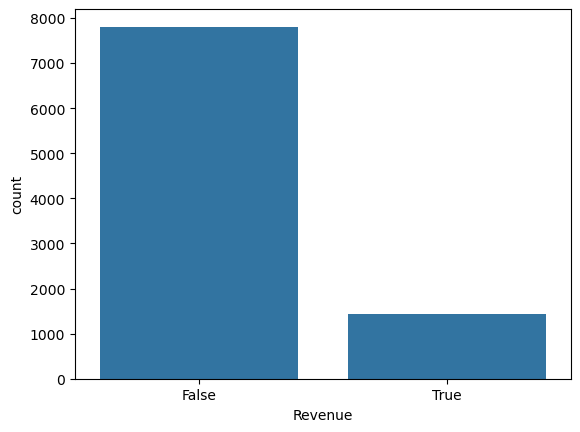

In [12]:
sns.countplot(x='Revenue', data=exp_data)
plt.show()

The target variable ``Revenue`` exhibits a clear class imbalance, with False representing the majority (7807 samples) and True the minority (1441 samples). Given this distribution, accuracy is not a reliable metric. Therefore, we will prioritize metrics like the F1-Score and utilize stratified splitting to maintain class proportions across training and test sets, ensuring the model is evaluated fairly on its ability to detect purchasing intent.

--- 

## Distribution of Features
Before investigating seperately the continuous and and categorical variables, let's see the correlation between different variables

### Correlation between features

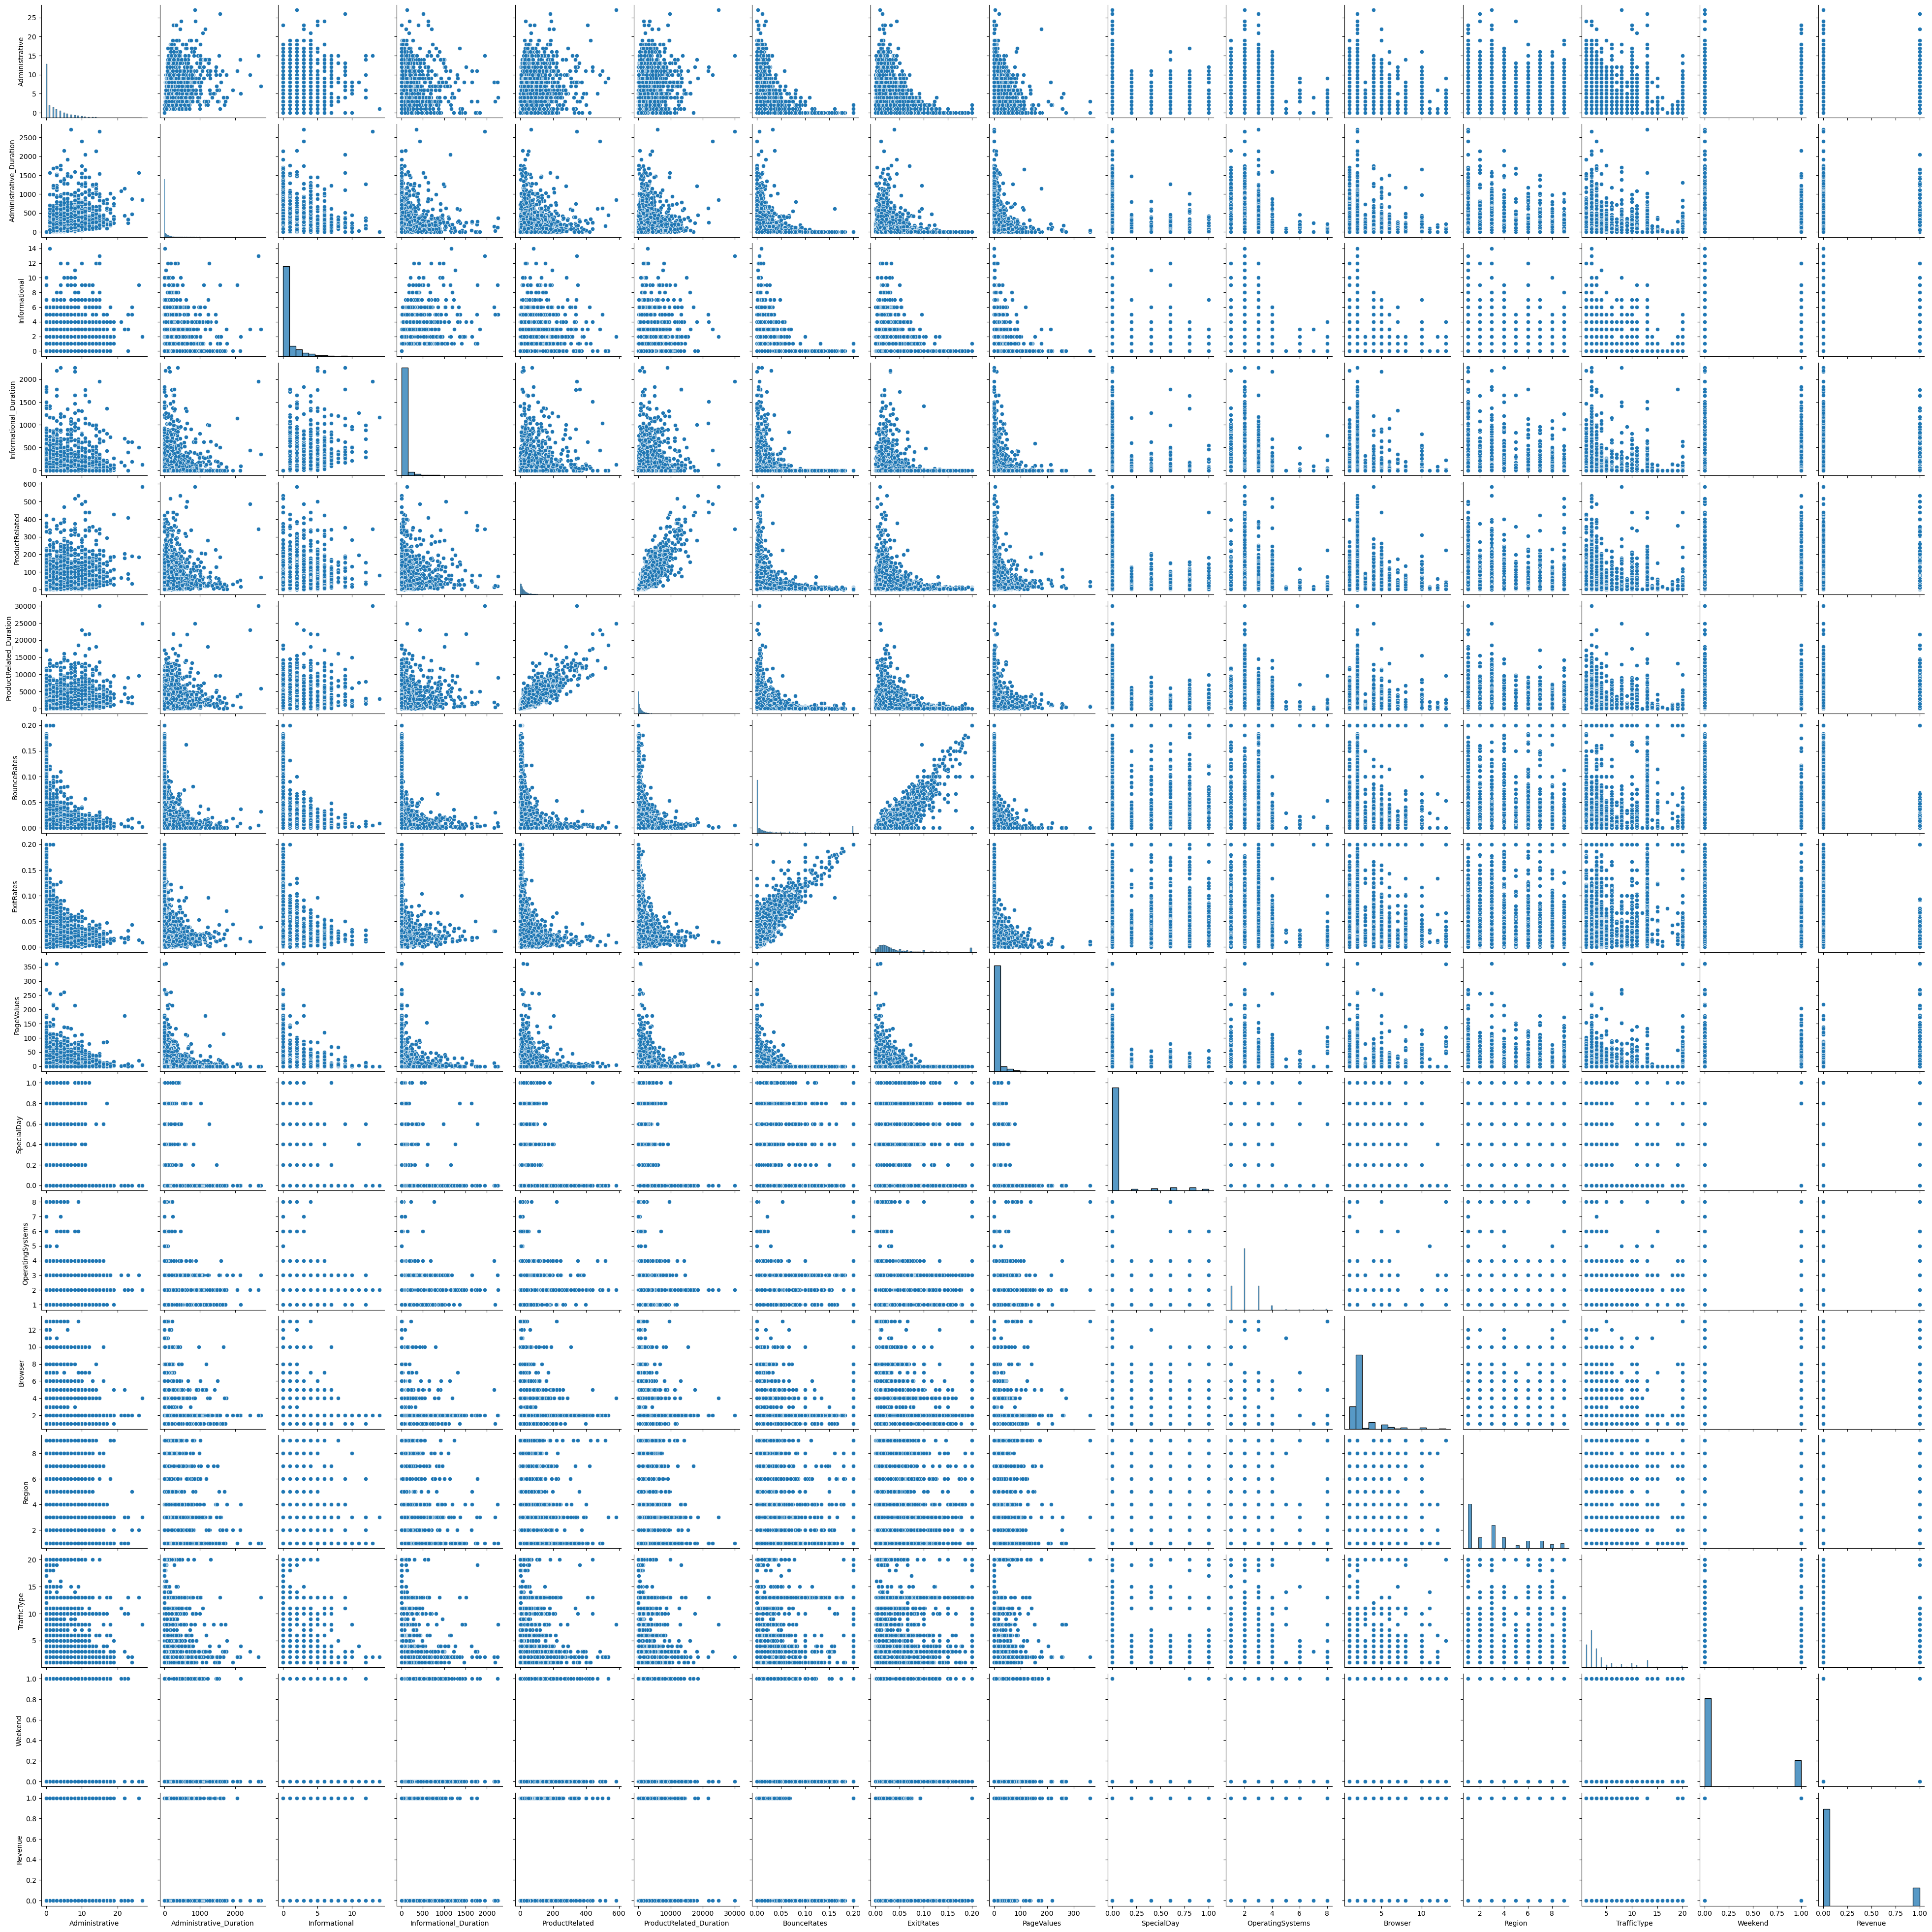

In [13]:
sns.pairplot(exp_data, height=2.5)
plt.show()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Weekend,Revenue
Administrative,1.000000,0.611851,0.375773,0.258137,0.419721,0.380945,-0.224850,-0.309846,0.094717,-0.102648,0.028321,0.134150
Administrative_Duration,0.611851,1.000000,0.289336,0.218854,0.259107,0.303871,-0.145781,-0.207051,0.067182,-0.080183,0.014885,0.091469
Informational,0.375773,0.289336,1.000000,0.616967,0.352429,0.377018,-0.116810,-0.156937,0.042454,-0.052272,0.034639,0.093716
Informational_Duration,0.258137,0.218854,0.616967,1.000000,0.266616,0.320617,-0.075360,-0.103809,0.028986,-0.032154,0.028703,0.066165
ProductRelated,0.419721,0.259107,0.352429,0.266616,1.000000,0.873362,-0.208201,-0.294423,0.053836,-0.032640,0.021780,0.162163
ProductRelated_Duration,0.380945,0.303871,0.377018,0.320617,0.873362,1.000000,-0.198554,-0.269676,0.055034,-0.045060,0.010219,0.164373
BounceRates,-0.224850,-0.145781,-0.116810,-0.075360,-0.208201,-0.198554,1.000000,0.912628,-0.121093,0.074986,-0.050657,-0.152728
ExitRates,-0.309846,-0.207051,-0.156937,-0.103809,-0.294423,-0.269676,0.912628,1.000000,-0.175136,0.107706,-0.069067,-0.208109
PageValues,0.094717,0.067182,0.042454,0.028986,0.053836,0.055034,-0.121093,-0.175136,1.000000,-0.064241,0.004976,0.485376
SpecialDay,-0.102648,-0.080183,-0.052272,-0.032154,-0.032640,-0.045060,0.074986,0.107706,-0.064241,1.000000,-0.017286,-0.082262


<Figure size 1200x1000 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Feature Correlation Matrix')

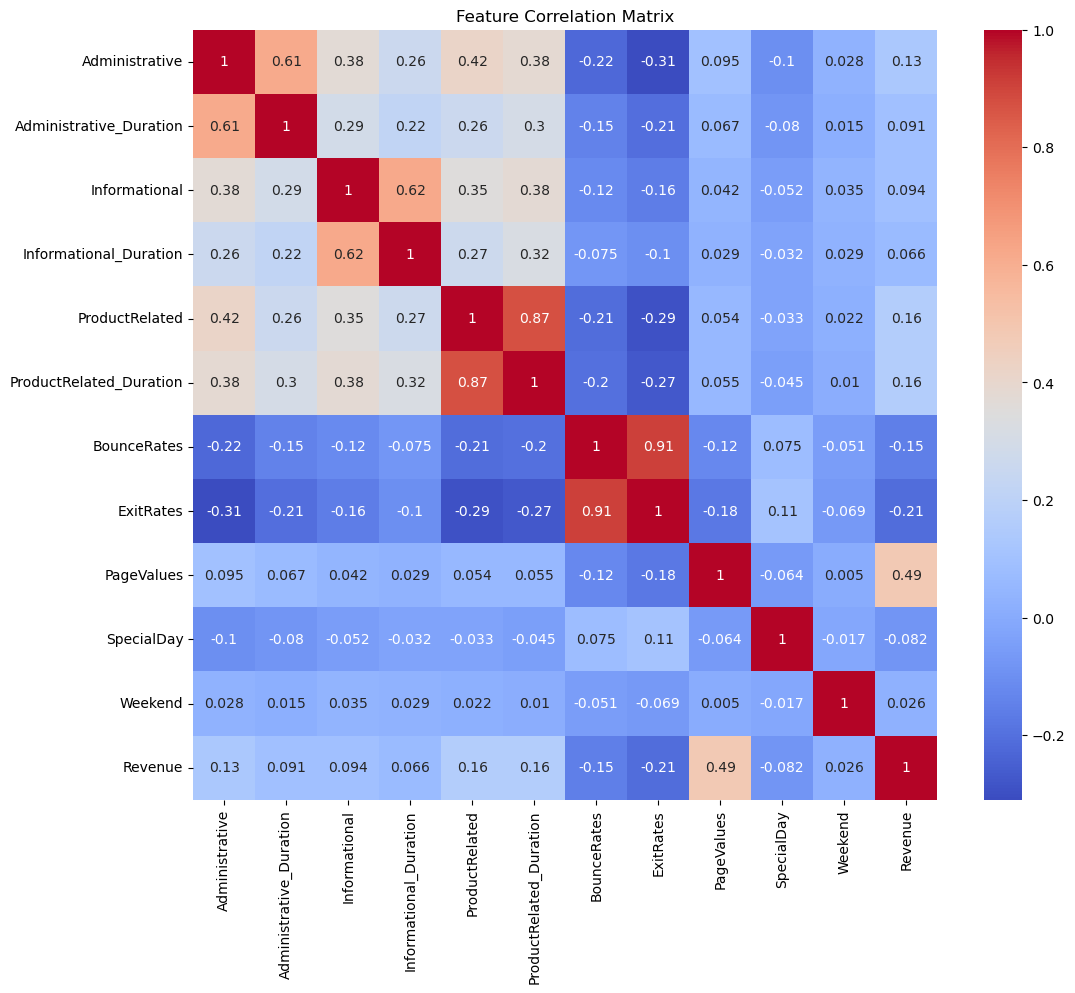

In [14]:
# We decided to remove nominal features in our correlation analysis
nominal_features = ["OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType", "Month"]
corr = exp_data.drop(nominal_features, axis=1).corr()
corr

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

By observing the heatmap with the most interesting features we can observe that:
- Some pairs (Administrative-Administrative_Duration, Product_based-Product_based_duration, ect.) are highly correlated features since they are measuring two sides of the same user behavior
- There is a moderate correlation between Revenue and PageValues, suggesting that Pagevalues can be a possible predictor of Revenue.
- Special day and weekend have very low correlation with all other features, likely representing noise in my data


Let's examine further the relationships of a selected subset of features with respect to ``Revenue``.

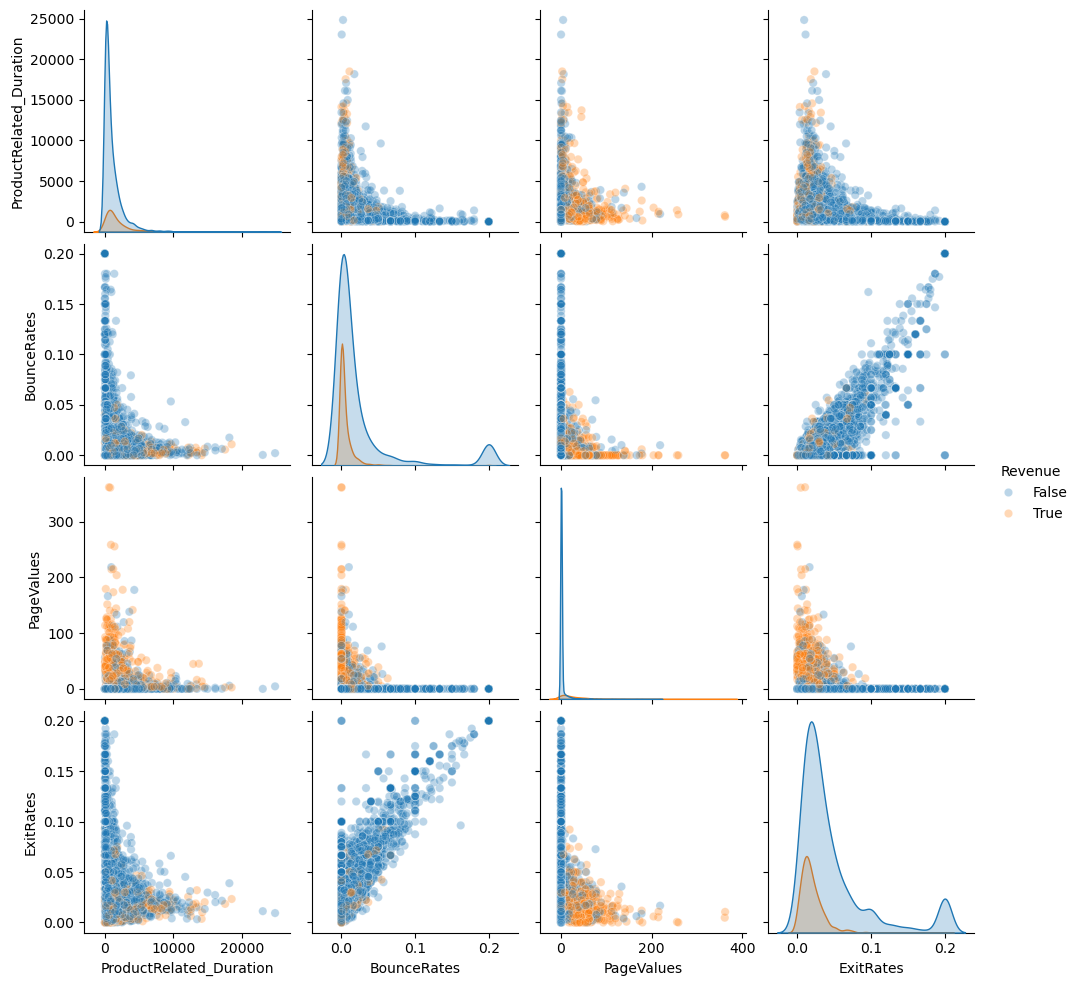

In [15]:
subset = ['ProductRelated_Duration', 'BounceRates', 'PageValues', 'ExitRates', 'Revenue']
sns.pairplot(exp_data[subset].dropna(), hue='Revenue', diag_kind='kde', plot_kws={'alpha':0.3})
plt.show()

#as expected highly correlated variable have a linear relationship

- The strong linear correlation between BounceRates and ExitRates confirms that these metrics capture nearly identical user disengagement behavior, suggesting redundancy in the feature set
- PageValues stands out as a discriminator with buying users showing higher values than the users who do not buy

### Continuous Features

<Axes: xlabel='Revenue', ylabel='Administrative'>

Text(0.5, 1.0, 'Boxplot of Administrative')

<Axes: xlabel='Revenue', ylabel='Administrative_Duration'>

Text(0.5, 1.0, 'Boxplot of Administrative_Duration')

<Axes: xlabel='Revenue', ylabel='Informational'>

...

Text(0.5, 1.0, 'Boxplot of BounceRates')

<Axes: xlabel='Revenue', ylabel='ExitRates'>

Text(0.5, 1.0, 'Boxplot of ExitRates')

<Axes: xlabel='Revenue', ylabel='PageValues'>

Text(0.5, 1.0, 'Boxplot of PageValues')

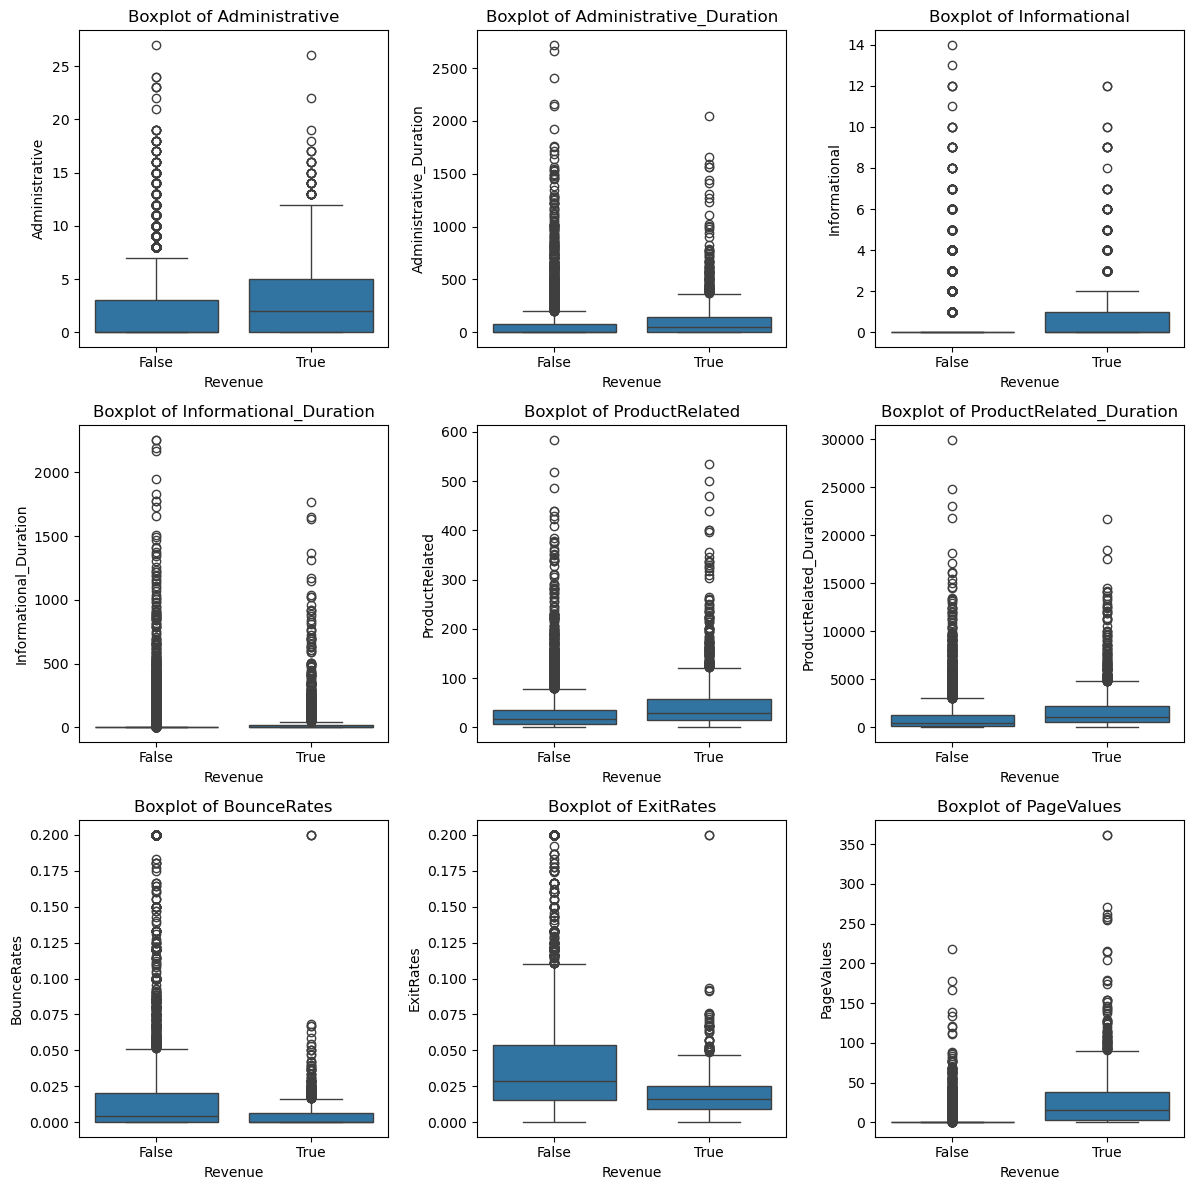

In [16]:
continuous = ['Administrative', 'Administrative_Duration', 'Informational',
             'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
             'BounceRates', 'ExitRates', 'PageValues']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 12))
plt.subplots_adjust(hspace=0.4)

for i, name in enumerate(continuous):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    sns.boxplot(data=exp_data, x="Revenue", y=name, ax=ax)
    ax.set_title("Boxplot of {}".format(name))

plt.tight_layout()
plt.show()

From the boxplots, it is interesting to see the boxplot of ``PageValues`` that the majority of users who do not generate revenue have ``PageValues`` near zero while the users that do generate revenue have high ``PageValues``. 
\
``BounceRates`` and ``ExitRates`` shows a very weak but interesting negative relationship with purchase behavior. Users who do not buy exhibit significantly higher and more volatile bounce and exit rates. Contrarily, customers who purchase tend to have a visible overall higher engagement
\
All of continuous features exhibit high concentration of outliers justifying a need for data scaling.


<Axes: xlabel='Administrative', ylabel='Count'>

Text(0.5, 1.0, 'Administrative')

<Axes: xlabel='Administrative_Duration', ylabel='Count'>

Text(0.5, 1.0, 'Administrative_Duration')

<Axes: xlabel='Informational', ylabel='Count'>

...

Text(0.5, 1.0, 'BounceRates')

<Axes: xlabel='ExitRates', ylabel='Count'>

Text(0.5, 1.0, 'ExitRates')

<Axes: xlabel='PageValues', ylabel='Count'>

Text(0.5, 1.0, 'PageValues')

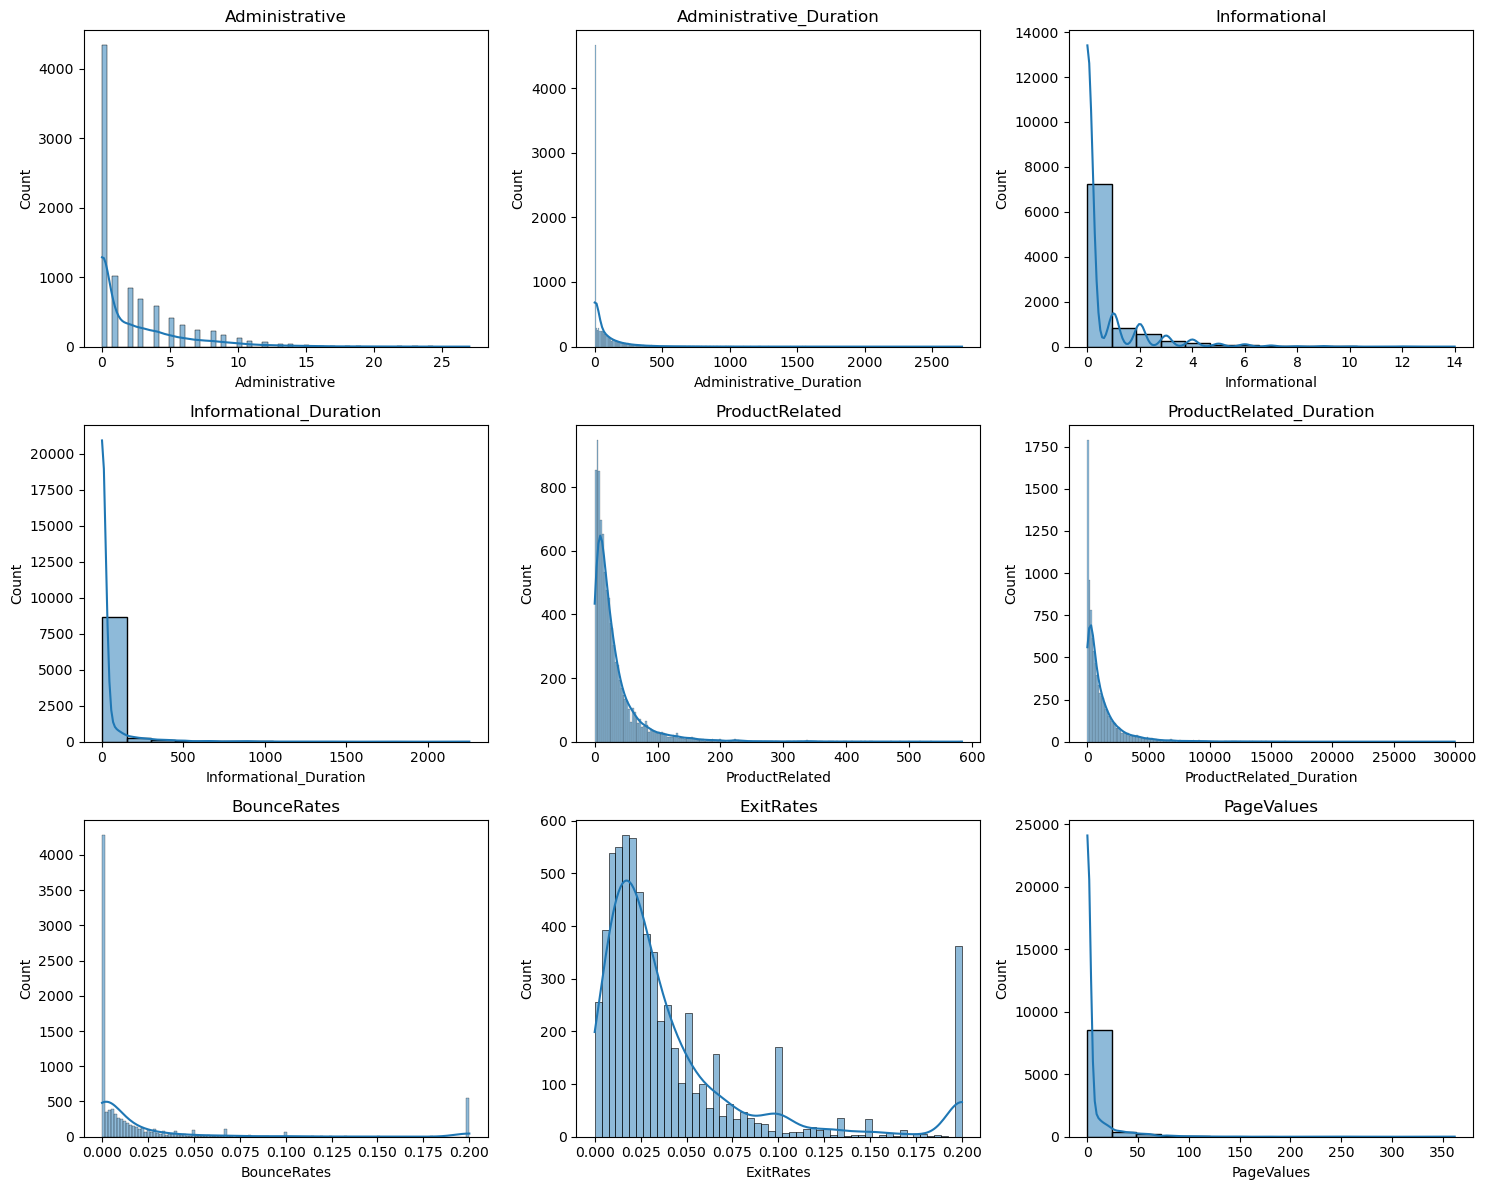

In [17]:
#histogram plot for the distribution of the continous variables
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flatten(), continuous):
    sns.histplot(exp_data[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### Categorical Variables

In [18]:
categorical_columns = ["OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType"]
exp_data[categorical_columns] = exp_data[categorical_columns].astype("category")

# We encoded Month as an ordered category to capture seasonality
month_order = ['Feb','Mar','May','June','Jul','Aug','Sep','Oct','Nov','Dec']
month_dtype = pd.CategoricalDtype(categories=month_order, ordered=True)
exp_data['Month'] = exp_data['Month'].astype(month_dtype)

categoricals = ["Month", "OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType"]

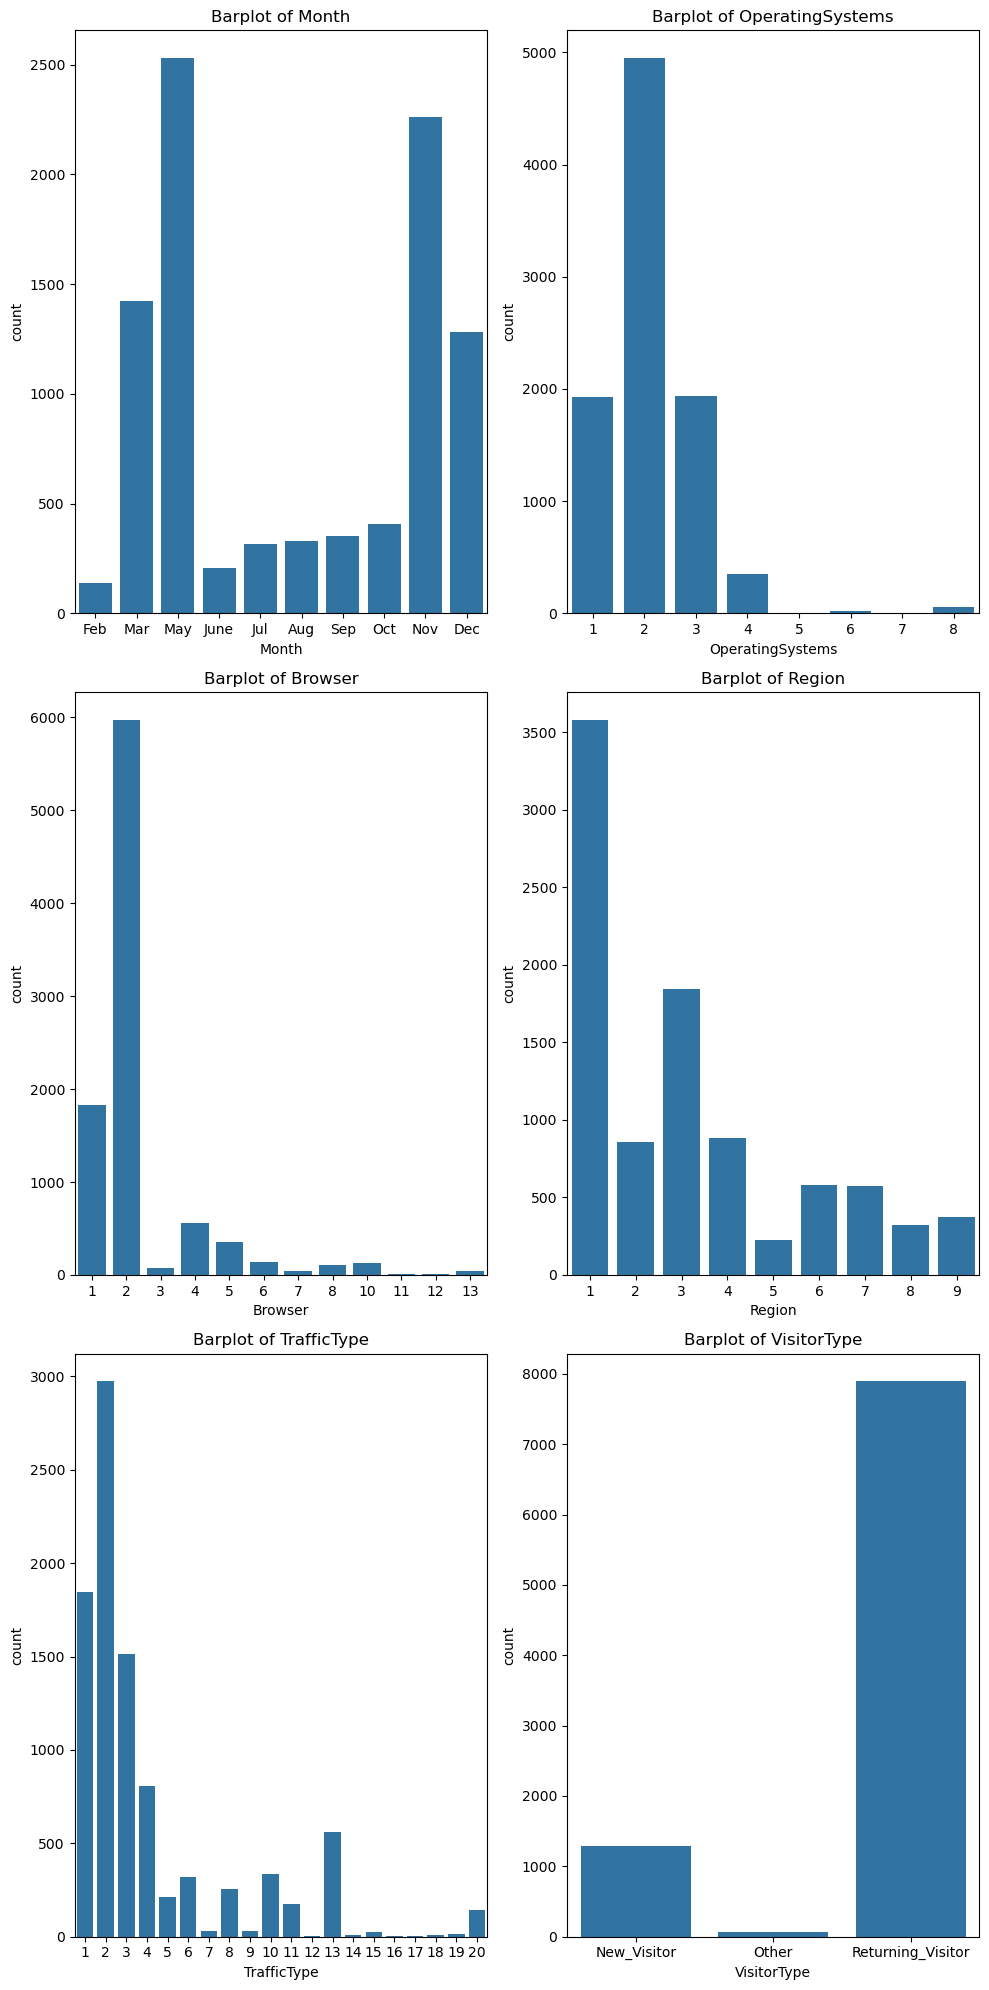

In [19]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 20))
for name in enumerate(categoricals):
    i, name = name
    sns.countplot(data=exp_data, x=name, ax=axes[i // 2, i % 2])
    axes[i // 2, i % 2].set_title("Barplot of {}".format(name))

plt.tight_layout()
plt.show();

### Categorical variables w.r.t. ``Revenue``

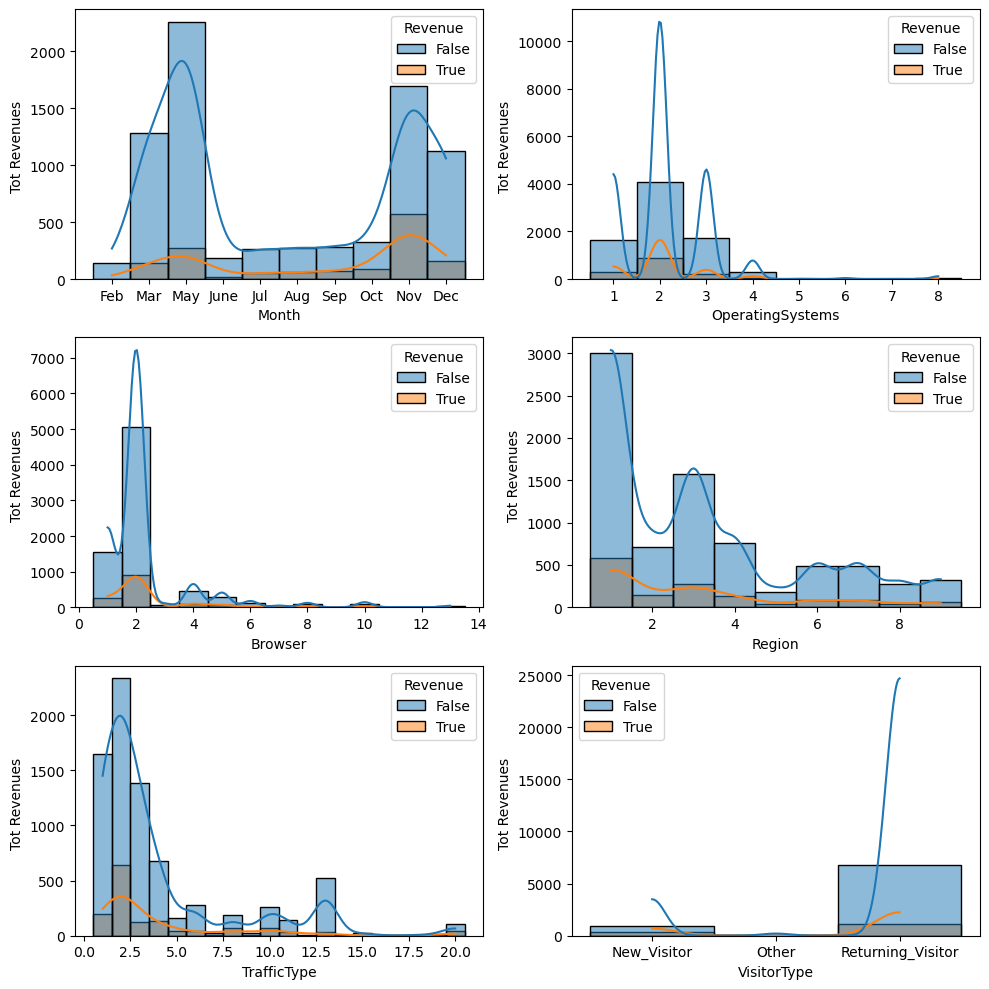

In [20]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10))
plt.subplots_adjust(hspace=0.4)

for i, categorical in enumerate(categoricals):
    ax = axes[i // 2, i % 2]  # Assign the correct axes to 'ax'
    sns.histplot(data=exp_data, x=categorical, hue="Revenue", kde=True, ax=ax)
    ax.set_xlabel(categorical)
    ax.set_ylabel("Tot Revenues ")

plt.tight_layout()
plt.show();

It is interesting to see clear seasonality in user behavior: May has a very high volume of non purchasing users while November shows an increase in purchases (likely holidays)
\
Returning visitors account for majority of revenue generation. Similarly, System 2 and Browser 2 are the most popular technical platforms.
\
Region distribution is unequal with region 1 dominating the traffic. 
The majority of site visitors arrive via a small number of primary traffic channels suggesting that only few sources are significant drivers of purchase. 



---
---

## 1.2 Regression

To recover the missing values in ``ExitRates``, we decided to evaluate different regressors.

### Encoding
Before proceeding, encoding is necessary to have a reliable model

In [21]:
#For TRAINING set
#Months were encoded using sine and cosine transformations to capture their cyclical nature. This preserves the temporal proximity between December and January, avoiding the 
# artificial discontinuity of integer encoding. As a result, seasonal patterns can be learned more effectively.
month_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "June": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
} 
train_data['Month'] = train_data['Month'].map(month_map)
train_data = pd.get_dummies(train_data, columns=["OperatingSystems","Browser","Region","TrafficType","VisitorType"])  #one-hot encoding 
train_data["Revenue"] = train_data["Revenue"].astype(int)  #transforming into a binary feature and not a boolean one
train_data["Weekend"] = train_data["Weekend"].astype(int)
train_data["month_sin"] = np.sin(2 * np.pi * train_data['Month'] / 12)
train_data["month_cos"] = np.cos(2 * np.pi * train_data['Month'] / 12)


#For TEST set
test_data['Month'] = test_data['Month'].map(month_map)
test_data = pd.get_dummies(test_data, columns=["OperatingSystems","Browser","Region","TrafficType","VisitorType"])
test_data["Revenue"] = test_data["Revenue"].astype(int) 
test_data["Weekend"] = test_data["Weekend"].astype(int)
test_data["month_sin"] = np.sin(2 * np.pi * test_data['Month'] / 12)
test_data["month_cos"] = np.cos(2 * np.pi * test_data['Month'] / 12)

In [22]:
#since we used a sine and cosine encoding, we will drop the 'Month' variable
test_data = test_data.drop(['Month'], axis = 1)
train_data = train_data.drop(['Month'], axis = 1)

In [23]:
#re-allinging in case columns between training and test are not aligned
#saving the columns
train_cols = train_data.columns
#reallining: 
test_data = test_data.reindex(columns=train_cols, fill_value=0)

In [24]:
train_data.isna().sum().sort_values(ascending=False)
test_data.isna().sum().sort_values(ascending=False)

train_data.columns

ExitRates         2782
Administrative       0
TrafficType_2        0
TrafficType_8        0
TrafficType_7        0
                  ... 
Browser_10           0
Browser_11           0
Browser_12           0
Browser_13           0
month_cos            0
Length: 66, dtype: int64

ExitRates         917
Administrative      0
TrafficType_2       0
TrafficType_8       0
TrafficType_7       0
                 ... 
Browser_10          0
Browser_11          0
Browser_12          0
Browser_13          0
month_cos           0
Length: 66, dtype: int64

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Weekend',
       'Revenue', 'OperatingSystems_1', 'OperatingSystems_2',
       'OperatingSystems_3', 'OperatingSystems_4', 'OperatingSystems_5',
       'OperatingSystems_6', 'OperatingSystems_7', 'OperatingSystems_8',
       'Browser_1', 'Browser_2', 'Browser_3', 'Browser_4', 'Browser_5',
       'Browser_6', 'Browser_7', 'Browser_8', 'Browser_10', 'Browser_11',
       'Browser_12', 'Browser_13', 'Region_1', 'Region_2', 'Region_3',
       'Region_4', 'Region_5', 'Region_6', 'Region_7', 'Region_8', 'Region_9',
       'TrafficType_1', 'TrafficType_2', 'TrafficType_3', 'TrafficType_4',
       'TrafficType_5', 'TrafficType_6', 'TrafficType_7', 'TrafficType_8',
       'TrafficType_9', 'TrafficType_10', 'TrafficType_11', 'TrafficType_12',
       'TrafficType_13', 'TrafficType_14', 'Tra

## Regression fitting 

To predict ``ExitRates`` missing values, we trained different regression algorithms:
- Linear regression
- Ridge
- Lasso
- Random Forest

In [25]:
copied_train = train_data[train_data['ExitRates'].notna()]

We exclude Revenue from the regression features when predicting Exit Rate, since Revenue is the target variable for a separate downstream classification task; including it here would let the recovered Exit Rate values indirectly encode information about Revenue, creating a form of label leakage once Exit Rate is later used as a feature to predict Revenue itself.

In [26]:
X = copied_train.drop(['ExitRates', 'Revenue'], axis=1)
y = copied_train['ExitRates']

print(X.columns)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'PageValues', 'SpecialDay', 'Weekend',
       'OperatingSystems_1', 'OperatingSystems_2', 'OperatingSystems_3',
       'OperatingSystems_4', 'OperatingSystems_5', 'OperatingSystems_6',
       'OperatingSystems_7', 'OperatingSystems_8', 'Browser_1', 'Browser_2',
       'Browser_3', 'Browser_4', 'Browser_5', 'Browser_6', 'Browser_7',
       'Browser_8', 'Browser_10', 'Browser_11', 'Browser_12', 'Browser_13',
       'Region_1', 'Region_2', 'Region_3', 'Region_4', 'Region_5', 'Region_6',
       'Region_7', 'Region_8', 'Region_9', 'TrafficType_1', 'TrafficType_2',
       'TrafficType_3', 'TrafficType_4', 'TrafficType_5', 'TrafficType_6',
       'TrafficType_7', 'TrafficType_8', 'TrafficType_9', 'TrafficType_10',
       'TrafficType_11', 'TrafficType_12', 'TrafficType_13', 'TrafficType_14',
       'TrafficType_15', 'TrafficTy

In [27]:
# We will compare different regression models using MSE so we define it here
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer

mean_squared_error = make_scorer(mean_squared_error, greater_is_better=False)


results = {}

To compare the performance of the different models, we use the Mean Squared Error (MSE) as the evaluation metric within a 5-fold cross-validation framework. The average MSE across the five validation folds provides a reliable estimate of the expected test error and allows for a fair comparison of the models' generalization performance. We then fit each regression model and store the corresponding cross-validation results in the 'results' dictionary. Finally, these results are summarized and plotted to facilitate the comparison and support the selection of the best-performing model.

### Linear Regression

In [28]:
from sklearn.linear_model import LinearRegression 

MultipleRegression = LinearRegression(fit_intercept= True)
scores_MR = cross_val_score(MultipleRegression, X, y, cv = 5, scoring=mean_squared_error)
abs(scores_MR) #to make more interpretable 
results['MultipleRegression'] = (abs(float(scores_MR.mean().round(6)))), abs(float(scores_MR.std().round(6)))

array([0.00040599, 0.00030327, 0.00032691, 0.00031319, 0.00027107])

### Forward feature selection 

In [29]:
#2.forward feature selection
from sklearn.feature_selection import SequentialFeatureSelector

sfs_forward = SequentialFeatureSelector(
    MultipleRegression,
    n_features_to_select= 'auto',       
    direction="forward",
    scoring= mean_squared_error,                  
    cv=5,                          
    n_jobs=-1                       
)

sfs_forward.fit(X, y)
selected_mask = sfs_forward.get_support()
selected_indices = np.where(selected_mask)[0]

print(selected_indices)

SequentialFeatureSelector(estimator=LinearRegression(), n_jobs=-1,
                          scoring=make_scorer(mean_squared_error, greater_is_better=False, response_method='predict'))

[ 0  1  2  4  5  6  7  8 10 11 14 15 16 18 22 27 35 36 38 39 40 41 42 45
 50 51 52 54 55 56 57 59]


In [34]:
selected_features = np.array(X.columns)[selected_mask]
print(selected_features)

X_forward = copied_train[selected_features]

scores_fw = cross_val_score(MultipleRegression, X_forward, y, cv = 5, scoring= mean_squared_error)
abs(scores_fw)
results['ForwardSelection'] = (abs(float(scores_fw.mean().round(4))), abs(float(scores_fw.std().round(4))))

['Administrative' 'Administrative_Duration' 'Informational'
 'ProductRelated' 'ProductRelated_Duration' 'BounceRates' 'PageValues'
 'SpecialDay' 'OperatingSystems_1' 'OperatingSystems_2'
 'OperatingSystems_5' 'OperatingSystems_6' 'OperatingSystems_7'
 'Browser_1' 'Browser_5' 'Browser_11' 'Region_6' 'Region_7' 'Region_9'
 'TrafficType_1' 'TrafficType_2' 'TrafficType_3' 'TrafficType_4'
 'TrafficType_7' 'TrafficType_12' 'TrafficType_13' 'TrafficType_14'
 'TrafficType_16' 'TrafficType_17' 'TrafficType_18' 'TrafficType_19'
 'VisitorType_New_Visitor']


array([0.00040181, 0.00029906, 0.00032755, 0.00030847, 0.00026887])

### Lasso

In [35]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(random_state=42))
])

param_grid = {
    'lasso__alpha': np.logspace(-4, 1, 50)
}

#searching the best parameter for the alpha with CV (selection of the tuning parameter)
grid_lasso = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=5,
    scoring= mean_squared_error,
    n_jobs=-1
)

# cross validation for the lasso with the best parameter choose ahead in the code
scores_lasso = cross_val_score(grid_lasso, X, y, cv=5, scoring= mean_squared_error)
results['Lasso'] = (abs(float(scores_lasso.mean().round(6))), abs(float(scores_lasso.std().round(6))))

### Ridge Regression

In [39]:
from sklearn.linear_model import Ridge


pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(random_state=42))
])

param_grid_ridge = {
    'ridge__alpha': np.logspace(-4, 1, 50)
}

# searching the best parameter for the alpha with CV (selection of the tuning parameter)
grid_ridge = GridSearchCV(
    pipe_ridge,
    param_grid=param_grid_ridge,
    cv=5,
    scoring= mean_squared_error,
    n_jobs=-1
)

# cross validation with the mean squared error
scores_ridge = cross_val_score(grid_ridge, X, y, cv=5, scoring=mean_squared_error)
results['Ridge'] = (abs(float(scores_ridge.mean().round(6))), abs(float(scores_ridge.std().round(6))))

### Random Forest

before running the random forest we applyed a cross validation apporach in order to select the best parameters in order to compare only one random forest model, the one that perfomed at best with the selected hyperparameters. 

In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor


param_grid = {
    "n_estimators": [100, 200, 500],
    "max_depth": [10, 20, None],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", 0.5]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring= mean_squared_error,
    n_jobs=-1
)
scores_rf = cross_val_score(
    grid_rf,
    X,
    y,
    cv=5,
    scoring= mean_squared_error
)

results['RandomForest'] = (
    abs(float(scores_rf.mean().round(6))),
    abs(float(scores_rf.std().round(6)))
) 


Exception ignored in: <function ResourceTracker.__del__ at 0x102c99d00>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Exception ignored in: <function ResourceTracker.__del__ at 0x1085f5d00>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  F

## Results for regression

In [40]:
pd.DataFrame(results, ['MSE', 'std'])

,MultipleRegression,ForwardSelection,Lasso,RandomForest,Ridge
MSE,0.000324,0.0003,0.000323,0.000171,0.000324
std,0.000045,0.0000,0.000045,0.000018,0.000045


Text(0, 0.5, 'Mean Squared Error')

Text(0.5, 1.0, 'Confronto modelli: MSE (mean ± std)')

[Text(0, 0, 'MultipleRegression'),
 Text(1, 0, 'ForwardSelection'),
 Text(2, 0, 'Lasso'),
 Text(3, 0, 'RandomForest'),
 Text(4, 0, 'Ridge')]

Text(0.0, 0.000324, '0.0003')

Text(1.0, 0.0003, '0.0003')

Text(2.0, 0.000323, '0.0003')

Text(3.0, 0.000171, '0.0002')

Text(4.0, 0.000324, '0.0003')

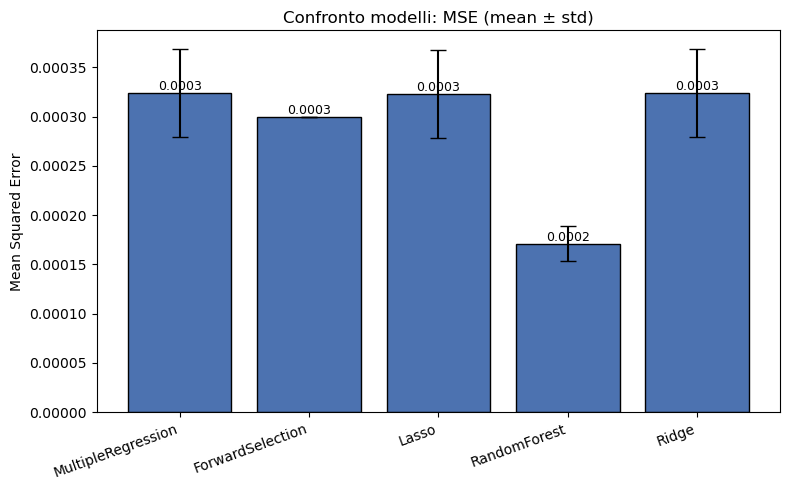

Exception ignored in: <function ResourceTracker.__del__ at 0x107495d00>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107481d00>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1077d5d00>
Traceback (most recent call last

In [ ]:
#results for regression algorithms:
keys = list(results.keys())
means = [v[0] for v in results.values()]
stds = [v[1] for v in results.values()]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(keys, means, yerr=stds, capsize=6, color="#4C72B0", edgecolor="black")

ax.set_ylabel("Mean Squared Error")
ax.set_title("Confronto modelli: MSE (mean ± std)")
ax.set_xticks(range(len(keys)))
ax.set_xticklabels(keys, rotation=20, ha="right")

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{mean:.4f}",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("mse_barplot.png", dpi=150)
plt.show()


To select optimal predictive model, we compared the MSE across our regressors. The random forest outperformed linear methods yielding the lowest average error. To address missing values, we decided to implement an iterative predictive imputation strategy using a Random Forest regressor.  The only drawback for the random forest approach is its complexity but since our primary goal is to maximize the accuracy of the filled data, we chose predictive robustness over interpretability.

## Fitting the best model

In [266]:
#fitting the grid_rf to print the best parameters
grid_rf.fit(X, y) 

print(grid_rf.best_estimator_)
print(grid_rf.best_score_) 

#building the random forest model with the best parameters
best_model = RandomForestRegressor(
    **grid_rf.best_params_, #selecting the best parameters
    random_state=42,
    n_jobs=-1
)

#fitting the model 
best_model.fit(X,y) 

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 0.5],
                         'min_samples_leaf': [1, 2, 5],
                         'n_estimators': [100, 200, 500]},
             scoring=make_scorer(mean_squared_error, greater_is_better=False, response_method='predict'))

RandomForestRegressor(max_depth=10, max_features=0.5, n_estimators=500,
                      random_state=42)
-0.00016940323722300512


RandomForestRegressor(max_depth=10, max_features=0.5, n_estimators=500,
                      n_jobs=-1, random_state=42)

----
---
---

# Task 2
_Use the regression model trained at the previous step to recover the Exit Rate by predicting its value for each missing sample on the train and test set. Build a classification model to predict whether an online shopper is likely to make a purchase. Perform feature selection, compare different algorithms, and identify the one that works the best on this dataset. Finally, test the best algorithm’s performance on the provided test set. Determine whether a model built using the Exit Rate information is better than a model built using the remaining features._

**2.1 Recovering ExitRates** \
**2.2 Classification with all features** \
**2.3 Feature selection**:
- Logistic lasso
- Forward Feature Selection
- Random Forest 

**2.4 Classification with selected features** \
**2.5 Performance on test set**

## 2.1 Filling NAs 

### Filling NAs in Training set

In [267]:
#filling the NaN:
print('before filling the NaN: ')
train_data.isna().sum().sort_values(ascending=False) 
#selecting the NaN value that we are gonna predict with all the feature present in the dataset
X_test = train_data.loc[
    train_data['ExitRates'].isna(),
    X.columns #the same defined before training the regressors 
]
#computing the prediciton given that X
pred = best_model.predict(X_test)
#assigning the prediction to the correspondet NaN in the training dataset:
train_data.loc[train_data['ExitRates'].isna(), 'ExitRates'] = pred
print('after filling: ')
#after
train_data.isna().sum().sort_values(ascending=False) 

before filling the NaN: 


ExitRates         2782
Administrative       0
TrafficType_2        0
TrafficType_8        0
TrafficType_7        0
                  ... 
Browser_10           0
Browser_11           0
Browser_12           0
Browser_13           0
month_cos            0
Length: 66, dtype: int64

after filling: 


Administrative    0
TrafficType_9     0
Region_4          0
Region_5          0
Region_6          0
                 ..
Browser_8         0
Browser_10        0
Browser_11        0
Browser_12        0
month_cos         0
Length: 66, dtype: int64

### Filling NAs in test set

We train the random forest with all the observation in our dataset to have a complete model to be used for predicting the 'Exit Rate' feature in the test set. 

In [268]:
#taking all the value in the training set
X_full = train_data[X.columns]
y_full = train_data['ExitRates']

#fitting a complete model
best_model.fit(X_full,y_full)


RandomForestRegressor(max_depth=10, max_features=0.5, n_estimators=500,
                      n_jobs=-1, random_state=42)

In [269]:
#filling the NaN in the test set:
X_test = test_data.loc[
    test_data['ExitRates'].isna(),
    X.columns
]
#computing the prediciton given that X
pred = best_model.predict(X_test)
#assigning the prediction to the correspondet NaN in the training dataset:
test_data.loc[test_data['ExitRates'].isna(), 'ExitRates'] = pred
print('after')
#after
test_data.isna().sum().sort_values(ascending=False) 

after


Administrative    0
TrafficType_9     0
Region_4          0
Region_5          0
Region_6          0
                 ..
Browser_8         0
Browser_10        0
Browser_11        0
Browser_12        0
month_cos         0
Length: 66, dtype: int64

--- 
---

# 2.2 Classification

For ``Revenue`` prediction we decided to use different classification algorithms:
- Logistic regression
- LDA
- QDA
- KNN
- SVM

We decided to compare their performances before with all features and then subsequently we performed feature selection to compare whether their performances improved.

In [270]:
from collections import OrderedDict
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC

X = train_data.drop(['Revenue'], axis=1)
y = train_data['Revenue']

X.columns


Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Weekend',
       'OperatingSystems_1', 'OperatingSystems_2', 'OperatingSystems_3',
       'OperatingSystems_4', 'OperatingSystems_5', 'OperatingSystems_6',
       'OperatingSystems_7', 'OperatingSystems_8', 'Browser_1', 'Browser_2',
       'Browser_3', 'Browser_4', 'Browser_5', 'Browser_6', 'Browser_7',
       'Browser_8', 'Browser_10', 'Browser_11', 'Browser_12', 'Browser_13',
       'Region_1', 'Region_2', 'Region_3', 'Region_4', 'Region_5', 'Region_6',
       'Region_7', 'Region_8', 'Region_9', 'TrafficType_1', 'TrafficType_2',
       'TrafficType_3', 'TrafficType_4', 'TrafficType_5', 'TrafficType_6',
       'TrafficType_7', 'TrafficType_8', 'TrafficType_9', 'TrafficType_10',
       'TrafficType_11', 'TrafficType_12', 'TrafficType_13', 'TrafficType_14',
       'TrafficType_15

## Classification with all features

/opt/anaconda3/lib/python3.13/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


,model,accuracy,accuracy_std,f1,f1_std,roc_auc,roc_auc_std
0,LDA,0.877919,0.005337,0.457727,0.028404,0.894091,0.012995
1,QDA,0.184368,0.023740,0.274915,0.006550,0.785893,0.014905
2,Logistic Regression,0.856508,0.010749,0.612776,0.025589,0.900347,0.012989
3,KNN,0.861051,0.005986,0.295943,0.027357,0.782594,0.015740
4,KNN + StandardScaler,0.853698,0.002116,0.152630,0.017617,0.743692,0.018115
5,KNN + MinMaxScaler,0.843101,0.002647,0.050956,0.010227,0.674497,0.012179
6,SVC (best parameters),0.831747,0.002434,0.375368,0.016906,0.777108,0.010223


Text(0, 0.5, 'Score')

Text(0.5, 1.0, 'Model comparison with all features')

(0.0, 1.0)

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'LDA'),
  Text(1, 0, 'QDA'),
  Text(2, 0, 'Logistic Regression'),
  Text(3, 0, 'KNN'),
  Text(4, 0, 'KNN + StandardScaler'),
  Text(5, 0, 'KNN + MinMaxScaler'),
  Text(6, 0, 'SVC (best parameters)')])

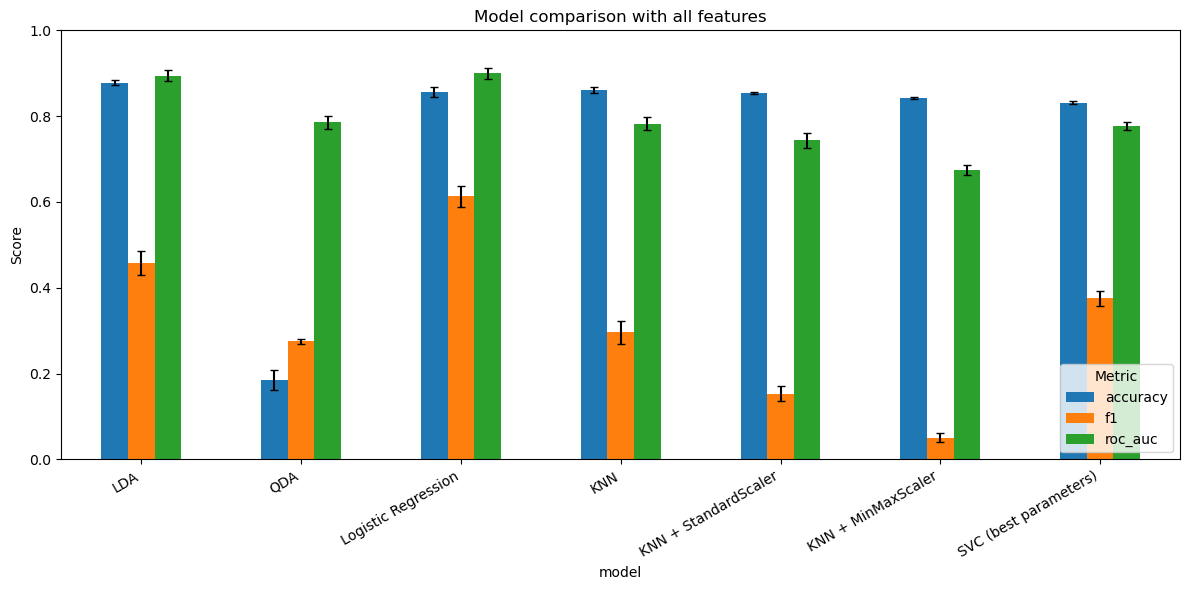

In [271]:
# We defined the models we use
lda = LDA()
qda = QDA()

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")

knn = KNeighborsClassifier(n_neighbors=11)

knn_std = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=16))
])

knn_minmax = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=17))
])

SVC_best = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(
        kernel='rbf',
        C=10,
        gamma=0.1,
        class_weight='balanced'
    ))
])

models = OrderedDict([
    ('LDA', lda),
    ('QDA', qda),
    ('Logistic Regression', log_reg),
    ('KNN', knn),
    ('KNN + StandardScaler', knn_std),
    ('KNN + MinMaxScaler', knn_minmax),
    ('SVC (best parameters)', SVC_best) #this are the models that we will test with all the features
])

# Compare models (CV with 5 folds only)
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

results_list = []
#performing the fitting and the scoring validation for each scoring and each model 
for name, model in models.items():
    cv_res = cross_validate(
        model, X, y,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )
    row = {'model': name}
    for metric in scoring:
        row[metric] = cv_res[f'test_{metric}'].mean()
        row[f'{metric}_std'] = cv_res[f'test_{metric}'].std()
    results_list.append(row)

#summarizing the results in a table
results = pd.DataFrame(results_list)
results

results_plot = results.set_index('model')

# selecting only the metrics and std columns
metric_cols = [c for c in results_plot.columns if not c.endswith('_std')]
std_cols = [c + '_std' for c in metric_cols]

means = results_plot[metric_cols]
stds = results_plot[std_cols]
stds.columns = metric_cols  

#now we proceed to plot the results in order to make more visible the comparison
ax = means.plot(
    kind='bar',
    figsize=(12, 6),
    yerr=stds,
    capsize=3
)
plt.ylabel("Score")
plt.title("Model comparison with all features")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right', title='Metric')
plt.tight_layout()
plt.show()

Based on these results, we can conclude that using all the available features, Logistic Regression is the best-performing classifier. It achieves an F1-score of approximately 0.60, outperforming all the other models considered. The second-best model is Linear Discriminant Analysis (LDA), suggesting that the decision boundary separating the two classes is predominantly linear. This observation is further supported by the relatively poor performance of the K-Nearest Neighbors (KNN) classifier, both with and without feature scaling. Since KNN is a non-parametric method that can model highly complex decision boundaries, its inferior performance indicates that such flexibility is unnecessary for this problem and may even lead to poorer generalization.

---

# 2.3 Feature Selection

We decided to use a LASSO approach for feature selection, given that a logistic regression model will be used to predict revenue. The choice of logistic regression was motivated by its superior performance compared to the other tested models when using the full set of features, as well as by its efficient implementation in the Scikit-learn framework. The objective is to identify the most relevant features contributing to the prediction while improving computational efficiency and interpretability. Since the LASSO solution is sparse, it naturally produces coefficient estimates that are exactly zero, effectively removing less informative features and retaining only those with the highest predictive contribution.

### Lasso

In [272]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

#cross validation to decide with penalty value is the best to use
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
C_scores = {}

for C in C_values:

    model = Pipeline([('scaler', StandardScaler()),
                      ('lasso', LogisticRegression(
                                penalty="l1",
                                C=C,
                                solver="liblinear",   
                                max_iter=1000,
                                class_weight="balanced" ))]) 
    # class_weight="balanced" to take into account the fact that the class 1 for revenue is not balanced

    scores= cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring= "f1")
    
    model.fit(X, y)
    
    lasso_model = model.named_steps['lasso']

    n_zero = np.sum(lasso_model.coef_ == 0) 

    C_scores[C] = (float(scores.mean().round(4)), float(n_zero))
print(C_scores)


Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(C=0.001, class_weight='balanced',
                                    max_iter=1000, penalty='l1',
                                    solver='liblinear'))])

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(C=0.01, class_weight='balanced',
                                    max_iter=1000, penalty='l1',
                                    solver='liblinear'))])

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=1000, penalty='l1',
                                    solver='liblinear'))])

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(C=1, class_weight='balanced', max_iter=1000,
                                    penalty='l1', solver='liblinear'))])

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(C=10, class_weight='balanced',
                                    max_iter=1000, penalty='l1',
                                    solver='liblinear'))])

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(C=100, class_weight='balanced',
                                    max_iter=1000, penalty='l1',
                                    solver='liblinear'))])

{0.001: (0.6519, 63.0), 0.01: (0.629, 48.0), 0.1: (0.6084, 12.0), 1: (0.6055, 4.0), 10: (0.6059, 3.0), 100: (0.6058, 0.0)}


In [273]:
#we don't have a lot of diverty in the f1 for each model, so taking into account the fact that we have a lot of variable we will go with the value of C = 0.01 that is
#between all the value that we trying in order to obtain a much simpler model to compare:
#even if is not the best score we choose a model with only the essential feature in order to have something more interpretable

Logist_Lasso = Pipeline([('scaler', StandardScaler()),
                      ('lasso', LogisticRegression(
                                penalty="l1",
                                C=0.01,
                                solver="liblinear",   
                                max_iter=1000,
                                class_weight="balanced"))])

Logist_Lasso.fit(X,y)

lasso_model = Logist_Lasso.named_steps['lasso']

coef = lasso_model.coef_.ravel()

selected_features = X.columns[np.abs(coef) > 1e-6]
print(list(selected_features))
print()
print(X.columns)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(C=0.01, class_weight='balanced',
                                    max_iter=1000, penalty='l1',
                                    solver='liblinear'))])

['Administrative', 'Informational', 'ProductRelated', 'ProductRelated_Duration', 'ExitRates', 'PageValues', 'Region_9', 'TrafficType_1', 'TrafficType_2', 'TrafficType_3', 'TrafficType_8', 'TrafficType_10', 'TrafficType_11', 'TrafficType_13', 'VisitorType_New_Visitor', 'month_sin', 'month_cos']

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Weekend',
       'OperatingSystems_1', 'OperatingSystems_2', 'OperatingSystems_3',
       'OperatingSystems_4', 'OperatingSystems_5', 'OperatingSystems_6',
       'OperatingSystems_7', 'OperatingSystems_8', 'Browser_1', 'Browser_2',
       'Browser_3', 'Browser_4', 'Browser_5', 'Browser_6', 'Browser_7',
       'Browser_8', 'Browser_10', 'Browser_11', 'Browser_12', 'Browser_13',
       'Region_1', 'Region_2', 'Region_3', 'Region_4', 'Region_5', 'Region_6',
       'Region_7', 'Region_8', 'R

In [274]:
#we redefine the X varaible with the selected feature by lasso:
X_selected = train_data[selected_features]


# 2.4 Classification models with selected features

given the size of the sample that we have we will fit different SVM model and
we will assess the quality only compare to the training set, then choosen the best 
through the f1 score, we will fit that model and use the CV approach to have a 
mean result to compare with the other model.


In [275]:
#SVM
from sklearn.svm import SVC
param_grid_svc = [
    {'kernel': ['linear'],'C':[0.01, 0.1, 1, 10]},
    {'kernel': ['rbf'], 'C':[0.01, 0.1, 1, 10], 'gamma': ['scale', 'auto', 0.01, 0.1]},
    {'kernel': ['poly'], 'C': [0.01, 0.1, 1, 10], 'degree': [2,3,4], 'gamma':['scale', 'auto']},
]

#feature scaling
scaler = StandardScaler()
X_train_std_svc = scaler.fit_transform(X_selected)

grid_svc = GridSearchCV(SVC(), param_grid_svc, cv = 5, scoring = 'f1', n_jobs = -1)
grid_svc.fit(X_train_std_svc, y)
print(grid_svc.best_params_)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid=[{'C': [0.01, 0.1, 1, 10], 'kernel': ['linear']},
                         {'C': [0.01, 0.1, 1, 10],
                          'gamma': ['scale', 'auto', 0.01, 0.1],
                          'kernel': ['rbf']},
                         {'C': [0.01, 0.1, 1, 10], 'degree': [2, 3, 4],
                          'gamma': ['scale', 'auto'], 'kernel': ['poly']}],
             scoring='f1')

{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

,model,accuracy,accuracy_std,f1,f1_std,roc_auc,roc_auc_std
0,LDA,0.877595,0.005695,0.454908,0.030653,0.898099,0.011774
1,QDA,0.823311,0.012393,0.502347,0.030440,0.820659,0.010090
2,Logistic Regression,0.860509,0.008979,0.621349,0.022531,0.902671,0.010317
3,KNN,0.873594,0.005024,0.450947,0.028402,0.831690,0.013828
4,KNN + StandardScaler,0.876946,0.005128,0.442272,0.029141,0.860120,0.009871
5,KNN + MinMaxScaler,0.857266,0.004679,0.250704,0.027750,0.806959,0.017172
6,SVC (best parameters),0.845156,0.006453,0.591578,0.014373,0.872366,0.005603


Text(0, 0.5, 'Score')

Text(0.5, 1.0, 'Model comparison with selected features')

(0.0, 1.0)

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'LDA'),
  Text(1, 0, 'QDA'),
  Text(2, 0, 'Logistic Regression'),
  Text(3, 0, 'KNN'),
  Text(4, 0, 'KNN + StandardScaler'),
  Text(5, 0, 'KNN + MinMaxScaler'),
  Text(6, 0, 'SVC (best parameters)')])

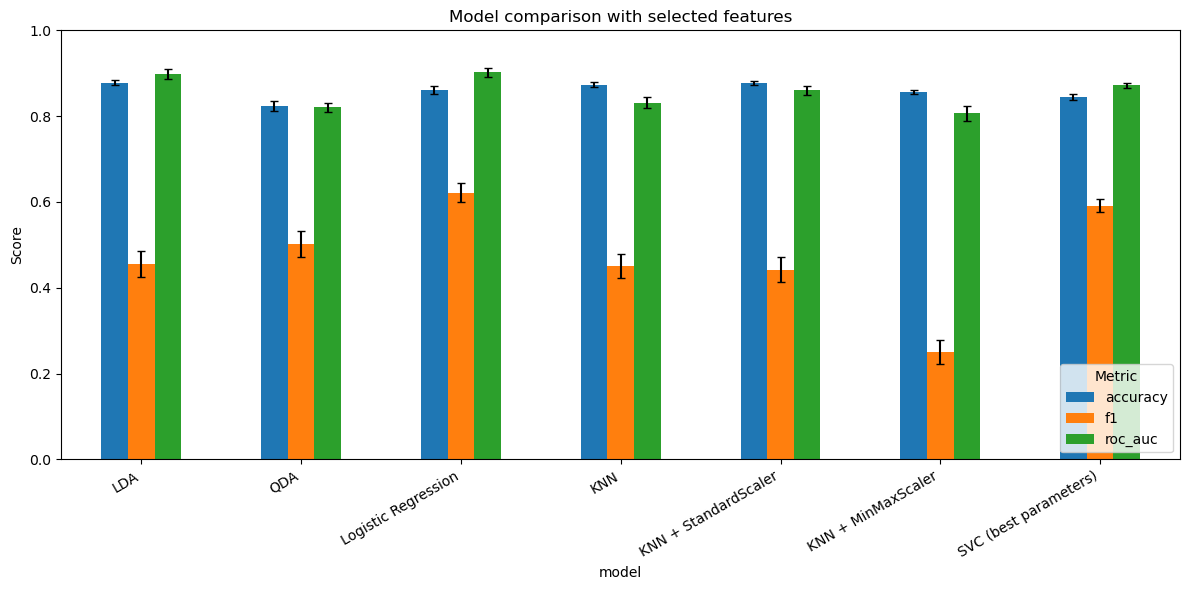

In [276]:
#now we will fit different classification model using only the selected feature:
from collections import OrderedDict

from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd

# Define models

lda = LDA()
qda = QDA()

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")

knn = KNeighborsClassifier(n_neighbors=11)

knn_std = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=16))
])

knn_minmax = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=17))
])

SVC_best = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(
        kernel='rbf',
        C=10,
        gamma=0.1,
        class_weight='balanced'
    ))
])

models = OrderedDict([
    ('LDA', lda),
    ('QDA', qda),
    ('Logistic Regression', log_reg),
    ('KNN', knn),
    ('KNN + StandardScaler', knn_std),
    ('KNN + MinMaxScaler', knn_minmax),
    ('SVC (best parameters)', SVC_best)
])

# Compare models (CV only)
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

results_list = []
for name, model in models.items():
    cv_res = cross_validate(
        model, X_selected, y,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )
    row = {'model': name}
    for metric in scoring:
        row[metric] = cv_res[f'test_{metric}'].mean()
        row[f'{metric}_std'] = cv_res[f'test_{metric}'].std()
    results_list.append(row)

results_selected = pd.DataFrame(results_list)
results_selected

#and now we print the same graph in order to compare the different models:

results_plot_selected = results_selected.set_index('model')

# Colonne delle metriche (senza le colonne _std)
metric_cols = [c for c in results_plot_selected.columns if not c.endswith('_std')]
std_cols = [c + '_std' for c in metric_cols]

means = results_plot_selected[metric_cols]
stds = results_plot_selected[std_cols]
stds.columns = metric_cols  # rinomino per allineare gli indici con means

ax = means.plot(
    kind='bar',
    figsize=(12, 6),
    yerr=stds,
    capsize=3
)
plt.ylabel("Score")
plt.title("Model comparison with selected features")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right', title='Metric')
plt.tight_layout()
plt.show()

As in the previous point, Logistic Regression remains the best-performing classifier, outperforming all the other models. Moreover, the model trained on the subset of features selected by LASSO achieves a slightly higher F1-score than the Logistic Regression model fitted using all the available features. Considering that our objective is not only to maximize predictive performance but also to obtain a model that is as interpretable as possible, we select the Logistic Regression model trained on the LASSO-selected features as the final classifier. This approach provides a good balance between predictive accuracy, model simplicity, and interpretability.

In [277]:
print(selected_features)

Index(['Administrative', 'Informational', 'ProductRelated',
       'ProductRelated_Duration', 'ExitRates', 'PageValues', 'Region_9',
       'TrafficType_1', 'TrafficType_2', 'TrafficType_3', 'TrafficType_8',
       'TrafficType_10', 'TrafficType_11', 'TrafficType_13',
       'VisitorType_New_Visitor', 'month_sin', 'month_cos'],
      dtype='object')


At this stage, we also examine the variables selected by LASSO to better understand which features are considered the most informative and to facilitate the interpretation of the best classifier model that will be fitted in the next step. The features selected by LASSO are consistent with the online purchasing process, as they mainly describe users' browsing behavior. In particular, ProductRelated and ProductRelated_Duration measure the level of interest in products, while Administrative and Informational capture the user's engagement before making a purchase. ExitRates reflects the likelihood of leaving the website without converting, whereas PageValues is one of the strongest predictors, as it estimates the value of the pages visited before the transaction. LASSO also retained TrafficType, VisitorType_New_Visitor, and the cyclic month variables (month_sin and month_cos), indicating that both the acquisition channel and seasonal effects influence purchasing behavior. Overall, the selected variables provide a meaningful and interpretable description of the factors driving purchase intention.

### Best Classifer: Logistic Regression

In [278]:
X_selected = train_data[selected_features]

best_classifier = Pipeline([('scaler', StandardScaler()),
                      ('lasso', LogisticRegression(
                                solver="liblinear",   
                                max_iter=1000,
                                class_weight="balanced"))])

best_classifier.fit(X_selected, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    solver='liblinear'))])

# 2.5 Best Classifier on Test Set

In [279]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
#now we can construct the confusion metrics and extract the test set error with a full report:
y_test = test_data['Revenue']
X_test = test_data[selected_features]

y_test_prediction = best_classifier.predict(X_test)

lr_results = {
    'Method': 'Logistic Regression (Supervised)',
    'accuracy': accuracy_score(y_test, y_test_prediction),
    'precision': precision_score(y_test, y_test_prediction),
    'recall': recall_score(y_test, y_test_prediction),
    'f1': f1_score(y_test, y_test_prediction),
    'roc_auc': roc_auc_score(y_test, y_test_prediction)
}
lr_results

{'Method': 'Logistic Regression (Supervised)',
 'accuracy': 0.8669695003244646,
 'precision': 0.5416058394160584,
 'recall': 0.7944325481798715,
 'f1': 0.6440972222222222,
 'roc_auc': np.float64(0.8371780331721538)}

In [280]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, recall_score, precision_score,
    roc_curve, auc
)

# Predictions (test set, Lasso-selected features) 
y_test_prediction = best_classifier.predict(X_test[selected_features_LASSO])
y_test_proba = best_classifier.predict_proba(X_test[selected_features_LASSO])[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_prediction)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

# Metrics 
accuracy = accuracy_score(y_test, y_test_prediction)
misclass = 1 - accuracy
sensitivity = recall_score(y_test, y_test_prediction)
precision = precision_score(y_test, y_test_prediction)
specificity = tn / (tn + fp)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Misclassification rate: {misclass:.4f}")
print(f"Sensitivity (recall): {sensitivity:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Specificity: {specificity:.4f}")


Confusion Matrix:
[[2301  314]
 [  96  371]]

Accuracy: 0.8670
Misclassification rate: 0.1330
Sensitivity (recall): 0.7944
Precision: 0.5416
Specificity: 0.8799


Text(0.5, 1.0, 'Confusion Matrix')

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix (%)')

Text(0.5, 25.722222222222214, 'Predicted label')

Text(688.0751633986929, 0.5, 'True label')

Text(0.5, 25.722222222222214, 'False Positive Rate')

Text(1172.3031045751634, 0.5, 'True Positive Rate')

Text(0.5, 1.0, 'ROC Curve')

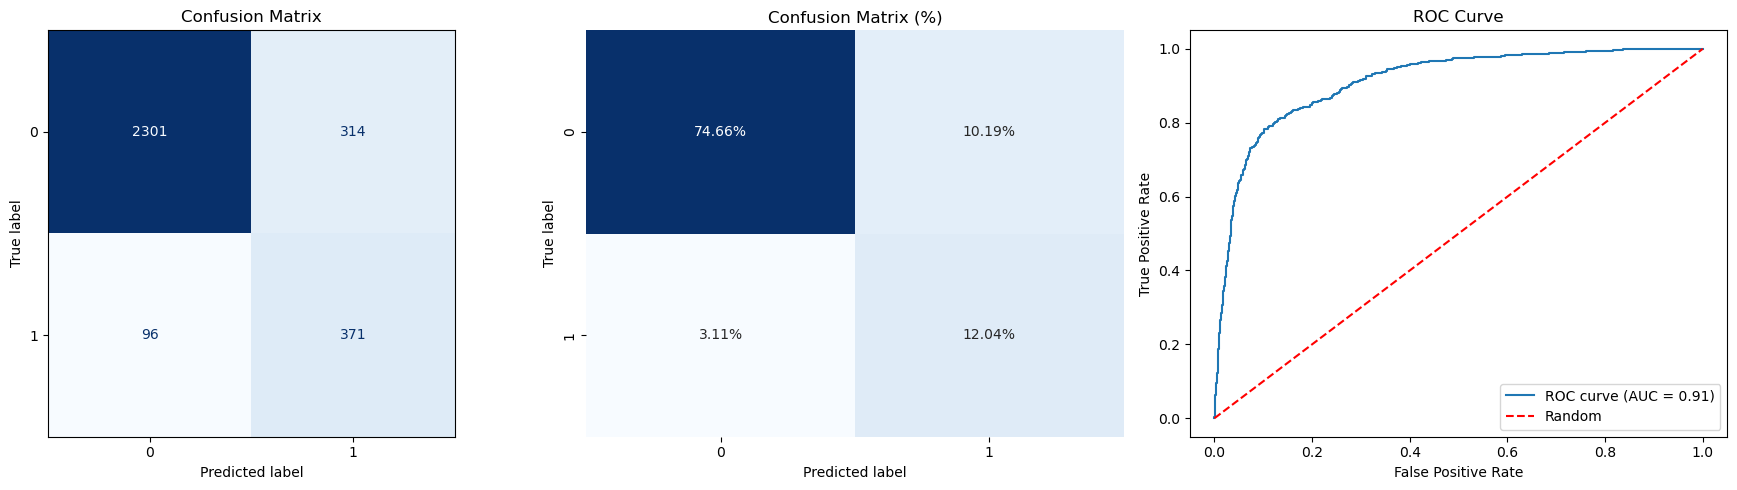

In [281]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)
# All three plots in one row 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix (counts)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

# Confusion matrix (percentages)
sns.heatmap(cm / np.sum(cm), annot=True, fmt='.2%', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title("Confusion Matrix (%)")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")

# ROC curve
axes[2].plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[2].plot([0, 1], [0, 1], linestyle='--', color='r', label='Random')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

Our final model (Logistic Regression, Lasso-selected features) achieves **86.7% accuracy** on the test set, 
correctly classifying the large majority of both buyers and non-buyers. However, given the ~85/15 class 
imbalance in Revenue, accuracy alone is not sufficient to judge performance — the other metrics tell a more 
complete story:

- **Sensitivity (Recall) = 0.794**: the model correctly identifies about 79% of actual buyers (371 out of 
  467 total buyers, i.e. 371 + 96 false negatives). This means roughly 1 in 5 real buyers are missed 
  (96 false negatives) — a meaningful limitation if the business goal is to catch as many potential 
  purchasers as possible (e.g., for targeted marketing interventions).
- **Precision = 0.542**: of all the samples the model flags as "will purchase," only about 54% actually do. 
  The remaining ~46% (314 false positives) are non-buyers incorrectly flagged as likely buyers.
- **Specificity = 0.880**: the model is quite good at correctly identifying non-buyers (88% of true 
  non-buyers are correctly classified), which is expected given they make up the majority class.

**Trade-off summary**: the model prioritizes recall over precision relative to a naive baseline, likely a 
consequence of using `class_weight='balanced'`, which penalizes misclassifying the minority (buyer) class 
more heavily. This is a reasonable choice for this business context: failing to identify a genuine potential 
buyer (false negative) is arguably more costly than mistakenly flagging a non-buyer as a lead (false 
positive), since the latter simply results in a wasted marketing touchpoint rather than a missed sale.

# Classification excluding ``ExitRates``

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

,model,accuracy,accuracy_std,f1,f1_std,roc_auc,roc_auc_std
0,LDA,0.877162,0.005845,0.454027,0.031545,0.896035,0.011602
1,QDA,0.830339,0.013578,0.488548,0.029760,0.811424,0.009551
2,Logistic Regression,0.861374,0.009480,0.622021,0.021929,0.903208,0.010897
3,KNN,0.873702,0.004859,0.451146,0.028258,0.831579,0.013832
4,KNN + StandardScaler,0.876838,0.004908,0.441999,0.029098,0.856640,0.007753
5,KNN + MinMaxScaler,0.859754,0.003209,0.278651,0.026054,0.819944,0.012055
6,SVC (best parameters),0.846669,0.006238,0.593909,0.013318,0.869422,0.006100


Text(0, 0.5, 'Score')

Text(0.5, 1.0, "Model comparison not including the 'Exit Rate' variable")

(0.0, 1.0)

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'LDA'),
  Text(1, 0, 'QDA'),
  Text(2, 0, 'Logistic Regression'),
  Text(3, 0, 'KNN'),
  Text(4, 0, 'KNN + StandardScaler'),
  Text(5, 0, 'KNN + MinMaxScaler'),
  Text(6, 0, 'SVC (best parameters)')])

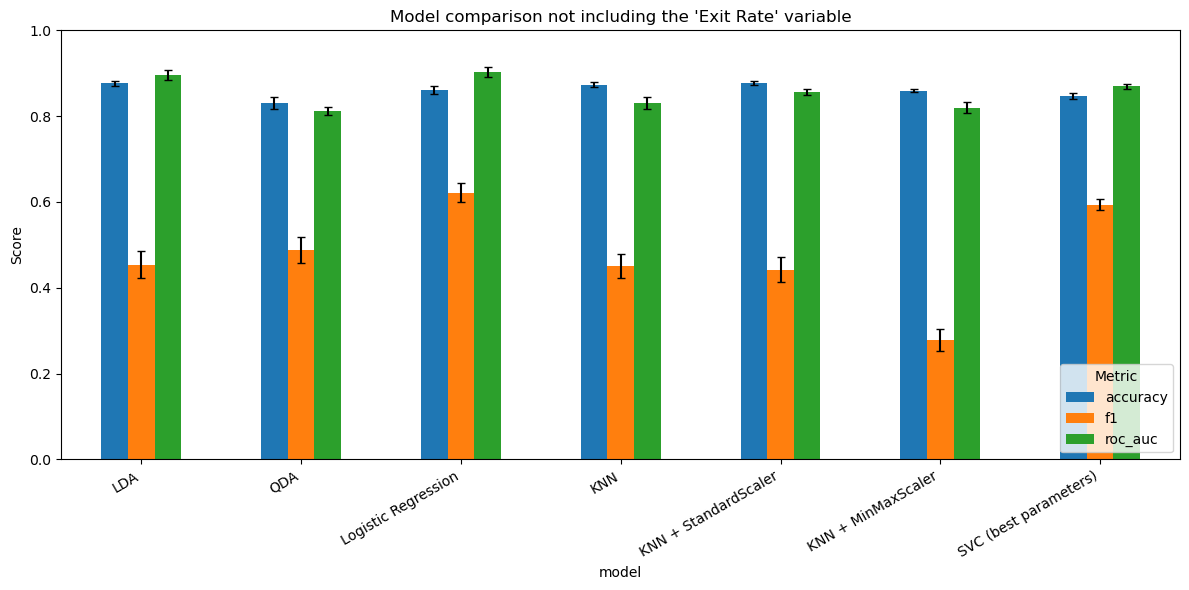

In [282]:
#recomputing the performance without the 'Exit Rate' feature in order to see if it adds something useful to the model: 

#redefinition of X_selected 
selected_feature_NOExitRates= ['Administrative', 'Informational', 'ProductRelated',
       'ProductRelated_Duration', 'PageValues', 'Region_9',
       'TrafficType_1', 'TrafficType_2', 'TrafficType_3', 'TrafficType_8',
       'TrafficType_10', 'TrafficType_11', 'TrafficType_13',
       'VisitorType_New_Visitor', 'month_sin', 'month_cos']

X_selected = train_data[selected_feature_NOExitRates]

# Define models

lda = LDA()
qda = QDA()

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")

knn = KNeighborsClassifier(n_neighbors=11)

knn_std = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=16))
])

knn_minmax = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=17))
])

SVC_best = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(
        kernel='rbf',
        C=10,
        gamma=0.1,
        class_weight='balanced'
    ))
])

models = OrderedDict([
    ('LDA', lda),
    ('QDA', qda),
    ('Logistic Regression', log_reg),
    ('KNN', knn),
    ('KNN + StandardScaler', knn_std),
    ('KNN + MinMaxScaler', knn_minmax),
    ('SVC (best parameters)', SVC_best)
])

# Compare models (CV only)

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

results_list = []
for name, model in models.items():
    cv_res = cross_validate(
        model, X_selected, y,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )
    row = {'model': name}
    for metric in scoring:
        row[metric] = cv_res[f'test_{metric}'].mean()
        row[f'{metric}_std'] = cv_res[f'test_{metric}'].std()
    results_list.append(row)

results_Noexitrates = pd.DataFrame(results_list)
results_Noexitrates

#and now we print the same graph in order to compare the different models:

results_plot_Noexitrates = results_Noexitrates.set_index('model')

# Colonne delle metriche (senza le colonne _std)
metric_cols = [c for c in results_plot_Noexitrates.columns if not c.endswith('_std')]
std_cols = [c + '_std' for c in metric_cols]

means = results_plot_Noexitrates[metric_cols]
stds = results_plot_Noexitrates[std_cols]
stds.columns = metric_cols  # rinomino per allineare gli indici con means

ax = means.plot(
    kind='bar',
    figsize=(12, 6),
    yerr=stds,
    capsize=3
)
plt.ylabel("Score")
plt.title("Model comparison not including the 'Exit Rate' variable")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right', title='Metric')
plt.tight_layout()
plt.show()

We obtain a little different in the results but at the end the best model is always the logistic regression (almost with the same value) so we would say that the Exit Rates do not make such difference in the model prediction in order to correctly classify 'Revenue'.
We will stay with the first model that include the 'Exit Rate' variable 

---
---
---

# Task 3 
_Repeat the analysis done at step 2 with clustering-based algorithms; compare the performance with respect to the best classification model_

As we did for the classification task we will fit diffent algorithms for clustering keeping in mind that our goal is to obtain 2 cluster as the two ``Revenue`` binary value and then we procedee with the comparison of the models.

## Dimensionality Reduction

In [283]:
#we will fit different clustering algorithm so in order to compute distance between points and be coherent with the datatype of that point we will first divide our dataset 
#into two datatypes as numerical and categorical

numerical_cols = [
    'Administrative', 'Administrative_Duration', 'Informational',
    'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
    'month_sin', 'month_cos'
]

categorical_cols = [
    'Weekend', 'VisitorType_Other', 'VisitorType_Returning_Visitor',
    'Browser_2', 'Browser_3', 'Browser_4', 'Browser_5', 'Browser_6',
    'Browser_7', 'Browser_8', 'Browser_10', 'Browser_11', 'Browser_12', 'Browser_13',
    'Region_2', 'Region_3', 'Region_4', 'Region_5', 'Region_6',
    'Region_7', 'Region_8', 'Region_9',
    'TrafficType_2', 'TrafficType_3', 'TrafficType_4', 'TrafficType_5',
    'TrafficType_6', 'TrafficType_7', 'TrafficType_8', 'TrafficType_9',
    'TrafficType_10', 'TrafficType_11', 'TrafficType_12', 'TrafficType_13',
    'TrafficType_14', 'TrafficType_15', 'TrafficType_16', 'TrafficType_17',
    'TrafficType_18', 'TrafficType_19', 'TrafficType_20',
    'OperatingSystems_2', 'OperatingSystems_3', 'OperatingSystems_4',
    'OperatingSystems_5', 'OperatingSystems_6', 'OperatingSystems_7', 'OperatingSystems_8'
]
y = train_data['Revenue'].astype(int)  # we will 'predict' the Revenue as in the classification case

PCA was not applied to the categorical variables because it relies on variance and linear combinations, which are meaningful only for continuous numerical data, not for nominal categories. It was therefore applied only to the numerical features, while Hamming distance was used to handle the categorical ones appropriately

## Numerical PCA

PCA()

<Figure size 800x500 with 0 Axes>

Text(0.5, 0, 'Number of Components')

Text(0, 0.5, 'Cumulative Explained Variance')

Text(0.5, 1.0, 'Cumulative Explained Variance by Number of Components')

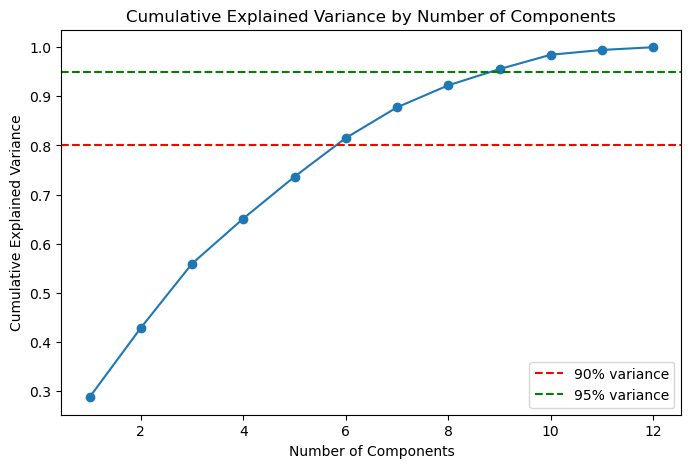

In [284]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

#selection only the numerical feature to apply PCA
X_NUM = train_data[numerical_cols]
# scaling before apply PCA (it's sensitive to it)
scaler = StandardScaler()
X_train_scaled_NUM = scaler.fit_transform(X_NUM)

# Fit PCA with no component limit, just to inspect variance
pca_NUM = PCA()
pca_NUM.fit(X_train_scaled_NUM)

cumulative_var = np.cumsum(pca_NUM.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o')
plt.axhline(y=0.80, color='r', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.title('Cumulative Explained Variance by Number of Components')
plt.show()

In [285]:
#given the plot we will select the number of PC that explain a resonably sourse of variability, in this case 6 (explain at least 80%)

pca_6 = PCA(n_components=6, random_state=42) #select 6 PC

X_NUMpca_array = pca_6.fit_transform(X_train_scaled_NUM) #fit the 6 pc for our dataset

pc_columns = [f"PC{i+1}" for i in range(6)]
X_pca_NUMfinal = pd.DataFrame(X_NUMpca_array, columns=pc_columns) #build a final dataframe


For two-dimensioanl visual rapresentation of the clustering that we could obtain we used different dimensionality reduction apply to the 6 PCs chosen before, this will further reduce the dimensionality in order to find to dimension for which the distance beetween points will be more or less the same compared to the PCA space

## UMAP

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Figure size 1000x700 with 0 Axes>

Text(0.5, 0, 'UMAP 1')

Text(0, 0.5, 'UMAP 2')

Text(0.5, 1.0, 'UMAP PCs=6')

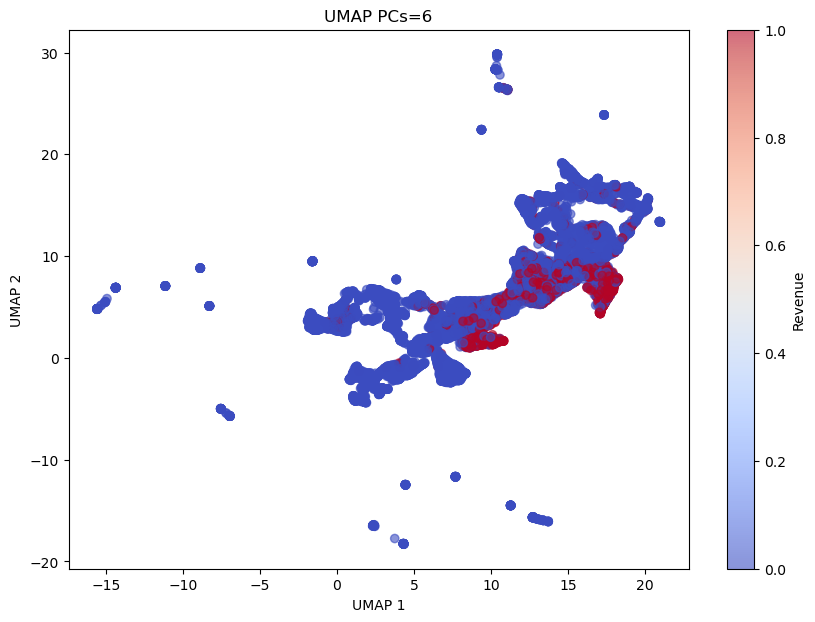

In [286]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_NUMpca_array)

# Plot
plt.figure(figsize=(10, 7))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='coolwarm', alpha=0.6)
plt.colorbar(label='Revenue')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP PCs=6')
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0.5, 0, 'UMAP 1')

Text(0.5, 0.5, 'UMAP 2')

Text(0.5, 0, 'UMAP 3')

Text(0.5, 0.92, 'UMAP 3D PCs=6')

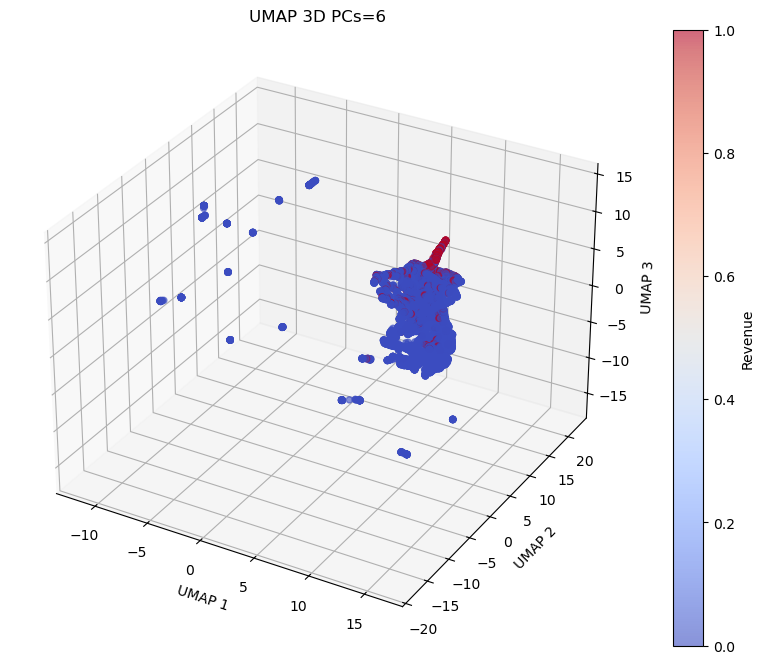

In [287]:
import umap
from mpl_toolkits.mplot3d import Axes3D

# Step 2: UMAP riduce a 3 componenti
reducer = umap.UMAP(n_components=3, random_state=42)
X_umap3d = reducer.fit_transform(X_NUMpca_array)

# Step 3: scatter plot 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X_umap3d[:, 0], X_umap3d[:, 1], X_umap3d[:, 2],
                 c=y, cmap='coolwarm', alpha=0.6)

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_zlabel('UMAP 3')
ax.set_title('UMAP 3D PCs=6')

fig.colorbar(sc, ax=ax, label='Revenue')
plt.show()

## t-SNE

<Figure size 1000x700 with 0 Axes>

Text(0.5, 0, 't-SNE 1')

Text(0, 0.5, 't-SNE 2')

Text(0.5, 1.0, 't-SNE 2D PCs=6')

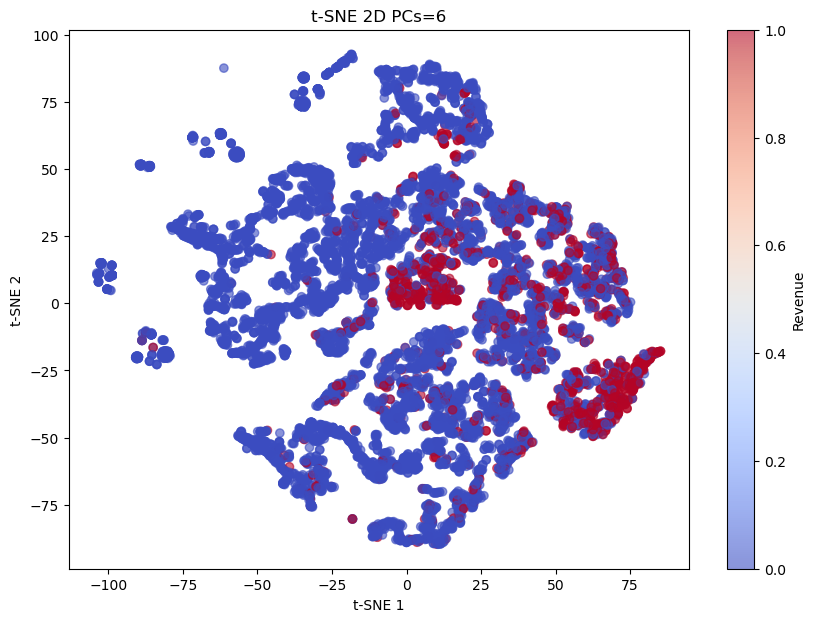

In [288]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne2d = tsne.fit_transform(X_NUMpca_array)

# Plot
plt.figure(figsize=(10, 7))
sc = plt.scatter(X_tsne2d[:, 0], X_tsne2d[:, 1], c=y, cmap='coolwarm', alpha=0.6)
plt.colorbar(sc, label='Revenue')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE 2D PCs=6')
plt.show()

Text(0.5, 0, 't-SNE 1')

Text(0.5, 0.5, 't-SNE 2')

Text(0.5, 0, 't-SNE 3')

Text(0.5, 0.92, 't-SNE 3D su PCs=6')

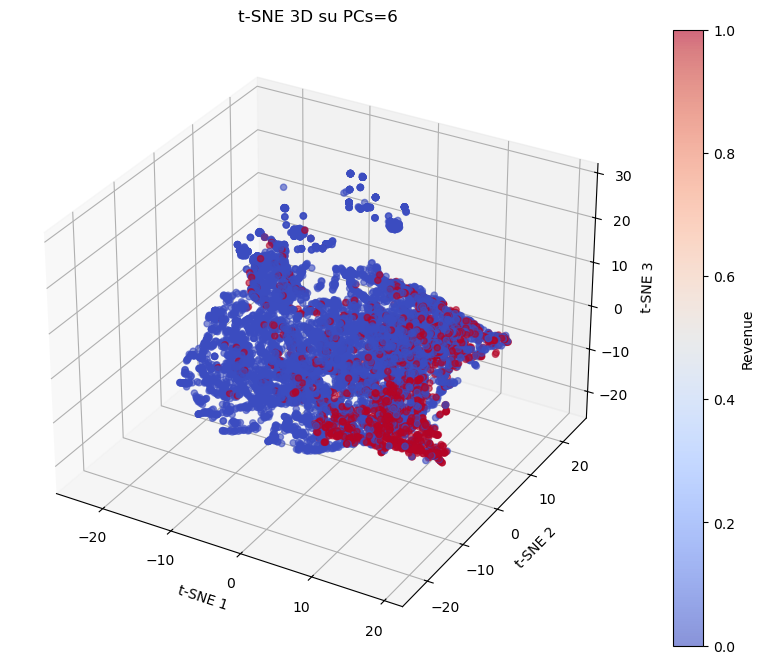

In [289]:
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

tsne = TSNE(n_components=3, random_state=42, perplexity=30)
X_tsne3d = tsne.fit_transform(X_NUMpca_array)

# Step 3: scatter plot 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X_tsne3d[:, 0], X_tsne3d[:, 1], X_tsne3d[:, 2],
                 c=y, cmap='coolwarm', alpha=0.6)

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_zlabel('t-SNE 3')
ax.set_title('t-SNE 3D su PCs=6')

fig.colorbar(sc, ax=ax, label='Revenue')
plt.show()

As we can notice there is no a clear separation in the two clusters given the two dimension found by UMAP and t-SNE, but this could be due only to the fact that we are further reducing the dimensionality. So could be that in the PCA space the points will be clearly split for the two clusters. 

---
---

# Clustering

### Metrics used for evaluation

In [290]:
#this will be the metrics definition for all the clustering that we are chosen, we will not use all the metrics at the end given that we have the label to predict 'Revenue' so we will stay 
# at the end with the external metrics comparison between algorithms.

import numpy as np
import pandas as pd
from sklearn.metrics import (
    jaccard_score, adjusted_rand_score, normalized_mutual_info_score,
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)


def compute_recall(cluster_labels, true_labels, cluster_index, class_label):
    cluster_indices = np.where(cluster_labels == cluster_index)[0]
    class_indices = np.where(true_labels == class_label)[0]
    nkj = len(np.intersect1d(cluster_indices, class_indices))
    nj = len(class_indices)
    return nkj / nj if nj > 0 else 0.0


def compute_precision(cluster_labels, true_labels, cluster_index, class_label):
    cluster_indices = np.where(cluster_labels == cluster_index)[0]
    class_indices = np.where(true_labels == class_label)[0]
    nkj = len(np.intersect1d(cluster_indices, class_indices))
    nk = len(cluster_indices)
    return nkj / nk if nk > 0 else 0.0


def evaluate_clustering(pred_labels, y, name="Model", X=None):
    """
    Evaluates a binary (2-cluster) clustering against a binary target.
    Aligns cluster labels with class labels to avoid arbitrary 0/1 swap penalties.
    If X is provided, also computes internal clustering-quality metrics.
    """
    y = np.asarray(y)
    pred_labels = np.asarray(pred_labels)

    n_cluster_0 = int(np.sum(pred_labels == 0))
    n_cluster_1 = int(np.sum(pred_labels == 1))

    # --- Align cluster labels with y (pick whichever mapping maximizes accuracy) ---
    acc_direct = np.mean(pred_labels == y)
    acc_swapped = np.mean((1 - pred_labels) == y)
    swapped = acc_swapped > acc_direct
    pred_aligned = (1 - pred_labels) if swapped else pred_labels
    acc = max(acc_direct, acc_swapped)

    # --- Per-cluster recall / precision (external, uses true labels) ---
    recall_0_0 = compute_recall(pred_aligned, y, 0, 0)
    recall_0_1 = compute_recall(pred_aligned, y, 0, 1)
    recall_1_0 = compute_recall(pred_aligned, y, 1, 0)
    recall_1_1 = compute_recall(pred_aligned, y, 1, 1)

    precision_0_0 = compute_precision(pred_aligned, y, 0, 0)
    precision_0_1 = compute_precision(pred_aligned, y, 0, 1)
    precision_1_0 = compute_precision(pred_aligned, y, 1, 0)
    precision_1_1 = compute_precision(pred_aligned, y, 1, 1)

    purity_0 = max(precision_0_0, precision_0_1)
    purity_1 = max(precision_1_1, precision_1_0)

    # --- External metrics (agreement with true labels) ---
    jaccard = jaccard_score(y, pred_aligned)
    ari = adjusted_rand_score(y, pred_labels)          # ARI/NMI are label-invariant, no need for alignment
    nmi = normalized_mutual_info_score(y, pred_labels)

    # --- Internal metrics (cluster quality, no labels needed) ---
    if X is not None:
        silhouette = silhouette_score(X, pred_labels)
        davies_bouldin = davies_bouldin_score(X, pred_labels)
        calinski_harabasz = calinski_harabasz_score(X, pred_labels)
    else:
        silhouette = davies_bouldin = calinski_harabasz = np.nan

    print(f"--- {name} ---")
    print(f"Cluster sizes: cluster 0 = {n_cluster_0}, cluster 1 = {n_cluster_1}")
    print(f"Accuracy (aligned): {acc:.4f}  {'(labels swapped)' if swapped else ''}")
    print(f"Purity: cluster 0 = {purity_0:.4f}, cluster 1 = {purity_1:.4f}")
    print(f"Jaccard: {jaccard:.4f} | ARI: {ari:.4f} | NMI: {nmi:.4f}")
    if X is not None:
        print(f"Silhouette: {silhouette:.4f} | Davies-Bouldin: {davies_bouldin:.4f} | Calinski-Harabasz: {calinski_harabasz:.2f}")
    print()

    return {
        'Method': name,
        'n_cluster_0': n_cluster_0,
        'n_cluster_1': n_cluster_1,
        'accuracy': acc,
        'recall_0_0': recall_0_0, 'recall_0_1': recall_0_1,
        'recall_1_0': recall_1_0, 'recall_1_1': recall_1_1,
        'precision_0_0': precision_0_0, 'precision_0_1': precision_0_1,
        'precision_1_0': precision_1_0, 'precision_1_1': precision_1_1,
        'purity_0': purity_0, 'purity_1': purity_1,
        'jaccard': jaccard,
        'ari': ari,
        'nmi': nmi,
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin,
        'calinski_harabasz': calinski_harabasz,
    }

## 1. K-means

We fitted a K-means algorithm only to numerical variabled scaled and then with PCA, we didn't consider categorical variables at all given that computing a mean for that variable would be impossibile (and reasonably do not make sense)

### All numerical

In [291]:
from sklearn.cluster import KMeans

#given that before we already computed a scaled version for the numerical one we will proced to fit a K-means with that feature 
#also we will use only 2 numer of cluster given that the revenue is a binary variable (0/1)
kmeans_NUM = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init="auto")
kmeans_NUM.fit(X_train_scaled_NUM)
pred_labels_NUM = kmeans_NUM.labels_

results_kmeans_NUM = evaluate_clustering(pred_labels_NUM, y, name="KMeans (Numerical, Scaled)", X=X_train_scaled_NUM)

KMeans(n_clusters=2, random_state=42)

--- KMeans (Numerical, Scaled) ---
Cluster sizes: cluster 0 = 4406, cluster 1 = 4842
Accuracy (aligned): 0.5643  
Purity: cluster 0 = 0.9287, cluster 1 = 0.7672
Jaccard: 0.2186 | ARI: 0.0155 | NMI: 0.0466
Silhouette: 0.1725 | Davies-Bouldin: 2.0640 | Calinski-Harabasz: 1569.60



### Numerical + PCA

In [292]:

kmeans_NUM_PCA = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init="auto")

pred_labels_NUM_PCA_kmeans = kmeans_NUM_PCA.fit_predict(X_pca_NUMfinal)

results_kmeans_NUM_PCA = evaluate_clustering(
    pred_labels_NUM_PCA_kmeans, 
    y, 
    name="KMeans (6 PCA Components)", X=X_pca_NUMfinal
)
print(results_kmeans_NUM_PCA)

--- KMeans (6 PCA Components) ---
Cluster sizes: cluster 0 = 4303, cluster 1 = 4945
Accuracy (aligned): 0.5621  
Purity: cluster 0 = 0.9366, cluster 1 = 0.7638
Jaccard: 0.2238 | ARI: 0.0131 | NMI: 0.0541
Silhouette: 0.2037 | Davies-Bouldin: 1.7780 | Calinski-Harabasz: 1956.60

{'Method': 'KMeans (6 PCA Components)', 'n_cluster_0': 4303, 'n_cluster_1': 4945, 'accuracy': np.float64(0.5620674740484429), 'recall_0_0': 0.5162034071986679, 'recall_0_1': 0.18945176960444135, 'recall_1_0': 0.48379659280133214, 'recall_1_1': 0.8105482303955587, 'precision_0_0': 0.9365558912386707, 'precision_0_1': 0.0634441087613293, 'precision_1_0': 0.7638018200202225, 'precision_1_1': 0.23619817997977754, 'purity_0': 0.9365558912386707, 'purity_1': 0.7638018200202225, 'jaccard': np.float64(0.2238405519356075), 'ari': 0.013099957972263102, 'nmi': np.float64(0.054118087643865366), 'silhouette': np.float64(0.20368546823827996), 'davies_bouldin': np.float64(1.777986156006393), 'calinski_harabasz': np.float64(1956

## 2. K-Medoids

### All numerical

In [293]:
from sklearn_extra.cluster import KMedoids

kmedoids_NUM = KMedoids(n_clusters=2, metric='euclidean', init='k-medoids++', random_state=42)
kmedoids_NUM.fit(X_train_scaled_NUM)
pred_labels_NUM_medoids = kmedoids_NUM.labels_

results_kmedoids_NUM = evaluate_clustering(pred_labels_NUM_medoids, y, name="KMedoids (Numerical, Scaled)", X=X_train_scaled_NUM)

KMedoids(init='k-medoids++', n_clusters=2, random_state=42)

--- KMedoids (Numerical, Scaled) ---
Cluster sizes: cluster 0 = 4646, cluster 1 = 4602
Accuracy (aligned): 0.5468  (labels swapped)
Purity: cluster 0 = 0.8929, cluster 1 = 0.7960
Jaccard: 0.1845 | ARI: 0.0087 | NMI: 0.0161
Silhouette: 0.1916 | Davies-Bouldin: 2.1497 | Calinski-Harabasz: 1369.81



### Categorical

In [294]:
#for the cateogrical in order to use the hamming distance we will not use the dummy variable present in our dataset but we apply a label encoder in order to make sense to compute an 
#hamming distance given our dummy variables:
from sklearn.preprocessing import LabelEncoder

train_cat_encoded = train_data[categorical_cols].apply(lambda col: LabelEncoder().fit_transform(col))


kmedoids_CAT = KMedoids(n_clusters=2, metric='hamming', init='k-medoids++', random_state=42)
kmedoids_CAT.fit(train_cat_encoded)
pred_labels_CAT_medoids = kmedoids_NUM.labels_

results_kmedoids_CAT = evaluate_clustering(pred_labels_CAT_medoids, y, name="KMedoids (Numerical, Scaled)", X=train_cat_encoded)

KMedoids(init='k-medoids++', metric='hamming', n_clusters=2, random_state=42)

--- KMedoids (Numerical, Scaled) ---
Cluster sizes: cluster 0 = 4646, cluster 1 = 4602
Accuracy (aligned): 0.5468  (labels swapped)
Purity: cluster 0 = 0.8929, cluster 1 = 0.7960
Jaccard: 0.1845 | ARI: 0.0087 | NMI: 0.0161
Silhouette: 0.0067 | Davies-Bouldin: 12.5883 | Calinski-Harabasz: 56.36



### Numerical + PCA

In [295]:
kmedoids_NUM = KMedoids(n_clusters=2, metric='euclidean', init='k-medoids++', random_state=42)
kmedoids_NUM.fit(X_pca_NUMfinal)
pred_labels_NUM_PCAmedoids= kmedoids_NUM.labels_

results_kmedoids_NUM_PCA = evaluate_clustering(pred_labels_NUM_PCAmedoids, y, name="KMedoids (Numerical, Scaled)", X=X_pca_NUMfinal)

KMedoids(init='k-medoids++', n_clusters=2, random_state=42)

--- KMedoids (Numerical, Scaled) ---
Cluster sizes: cluster 0 = 4585, cluster 1 = 4663
Accuracy (aligned): 0.5610  
Purity: cluster 0 = 0.9086, cluster 1 = 0.7808
Jaccard: 0.2011 | ARI: 0.0148 | NMI: 0.0283
Silhouette: 0.2285 | Davies-Bouldin: 1.8433 | Calinski-Harabasz: 1769.66



## Hierarchical

We selected average linkage for hierarchical clustering because it merges clusters according to the average distance between all pairs of observations, since our clusters are unbalanced given the UMAP/t-SNE rappresentation seen before. 

In [296]:
#importing the model and definition of the function used to plot the dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

distance_threshold=None

def plot_dendrogram(Z=None, model=None, X=None, **kwargs):
    annotate_above = kwargs.pop('annotate_above', 0)

    # Reconstruct the linakge matrix if the standard model API was used
    if Z is None:
        if hasattr(model, 'distances_') and model.distances_ is not None:
            # create the counts of samples under each node
            counts = np.zeros(model.children_.shape[0])
            n_samples = len(model.labels_)
            for i, merge in enumerate(model.children_):
                current_count = 0
                for child_idx in merge:
                    if child_idx < n_samples:
                        current_count += 1  # leaf node
                    else:
                        current_count += counts[child_idx - n_samples]
                counts[i] = current_count

            Z = np.column_stack([model.children_, model.distances_,
                                              counts]).astype(float)
        else:
            Z = linkage(X, method=model.linkage, metric=model.metric)
    
    if 'n_clusters' in kwargs:
        n_clusters = kwargs.pop('n_clusters')
        # Set the cut point just above the last but 'n_clusters' merge
        kwargs['color_threshold'] = Z[-n_clusters, 2] + 1e-6
    
    fig = plt.figure(figsize=(20,10))
    ax = fig.add_subplot(111)
    # Plot the corresponding dendrogram
    ddata = dendrogram(Z, ax=ax, **kwargs) 
    
    # Annotate nodes in the dendrogram
    for i, d, c in zip(ddata['icoord'], ddata['dcoord'], ddata['color_list']):
        x = 0.5 * sum(i[1:3])
        y = d[1]
        nid = np.where(Z[:,2] == y)[0][0]
        if y > annotate_above:
            plt.plot(x, y, 'o', c=c)
            plt.annotate(str(nid-Z.shape[0]), (x, y), xytext=(0, -5),
                         textcoords='offset points',
                         va='top', ha='center')
    if kwargs['color_threshold']:
        plt.axhline(y=kwargs['color_threshold'], c='k')
    
    return fig, ax

### All numerical

In [297]:
from sklearn.cluster import AgglomerativeClustering
hierarchical_cluster = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='average')
pred_labels_NUM = hierarchical_cluster.fit_predict(X_NUM) #used only the numerical one and not the scaled

results_hierarchical_NUM = evaluate_clustering(pred_labels_NUM, y, name="Hierarchical(Numerical)", X=X_NUM)

--- Hierarchical(Numerical) ---
Cluster sizes: cluster 0 = 44, cluster 1 = 9204
Accuracy (aligned): 0.8433  (labels swapped)
Purity: cluster 0 = 0.8454, cluster 1 = 0.5909
Jaccard: 0.0123 | ARI: 0.0123 | NMI: 0.0038
Silhouette: 0.8851 | Davies-Bouldin: 0.2843 | Calinski-Harabasz: 3538.06



(<Figure size 2000x1000 with 1 Axes>, <Axes: >)

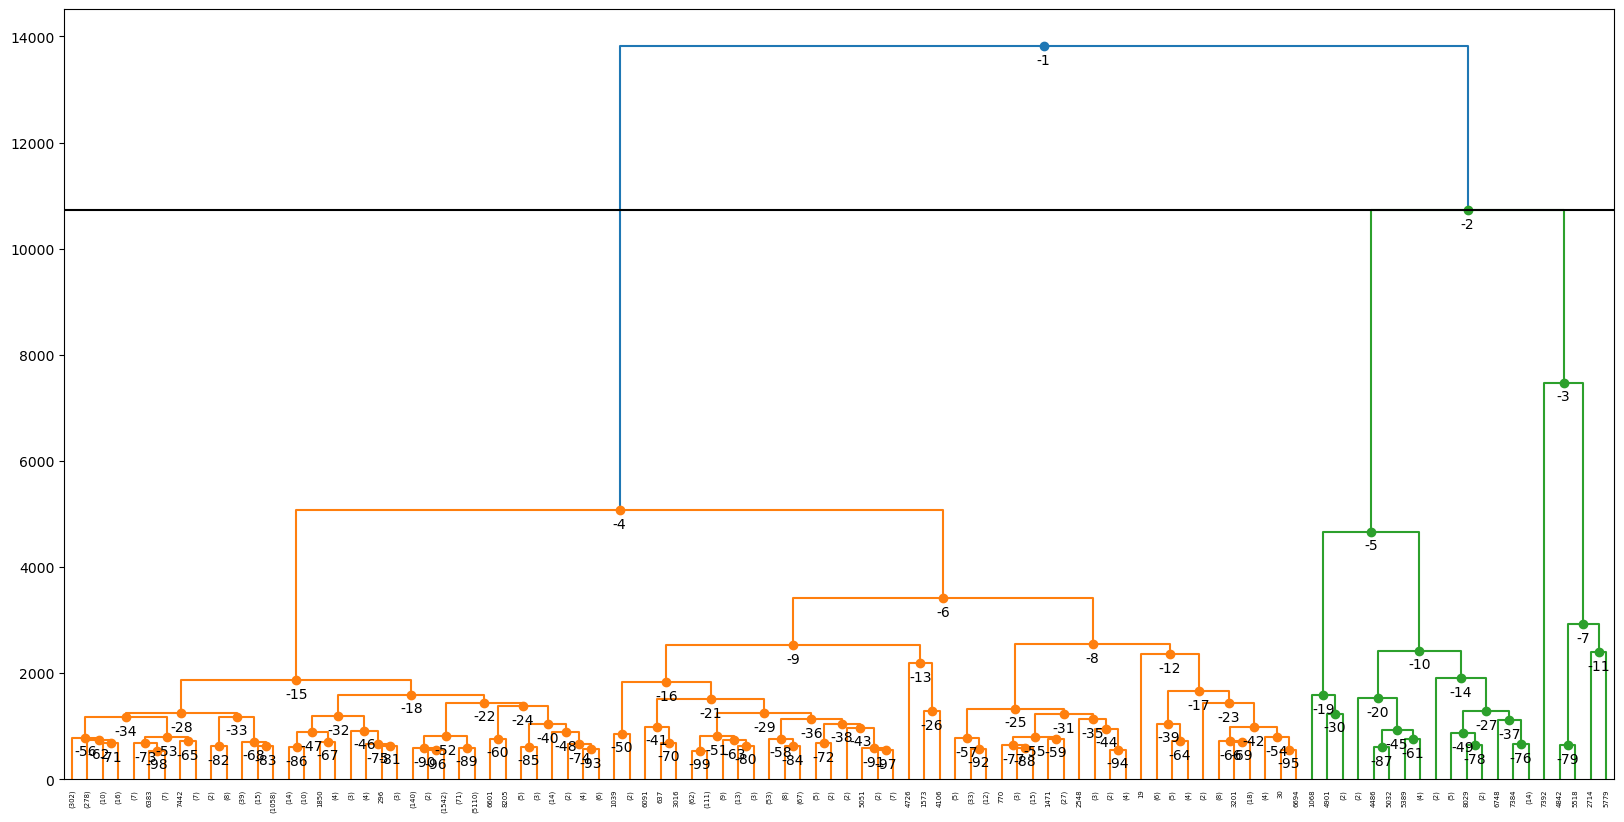

In [298]:

plot_dendrogram(model=hierarchical_cluster, X=X_NUM, truncate_mode='lastp', p=100, 
                n_clusters=2, 
                color_threshold=distance_threshold)

plt.show()

### Categorical

In [299]:
agg_CAT = AgglomerativeClustering(n_clusters=2, metric='hamming', linkage='average')
pred_labels_CAT_agg = agg_CAT.fit_predict(train_cat_encoded)

results_hierarchical_CAT = evaluate_clustering(pred_labels_CAT_agg, y, name="Hierarchical(Categorical, Hamming)", X=train_cat_encoded)

--- Hierarchical(Categorical, Hamming) ---
Cluster sizes: cluster 0 = 9205, cluster 1 = 43
Accuracy (aligned): 0.8421  
Purity: cluster 0 = 0.8448, cluster 1 = 0.7209
Jaccard: 0.0082 | ARI: 0.0059 | NMI: 0.0010
Silhouette: 0.2724 | Davies-Bouldin: 0.9122 | Calinski-Harabasz: 100.83



(<Figure size 2000x1000 with 1 Axes>, <Axes: >)

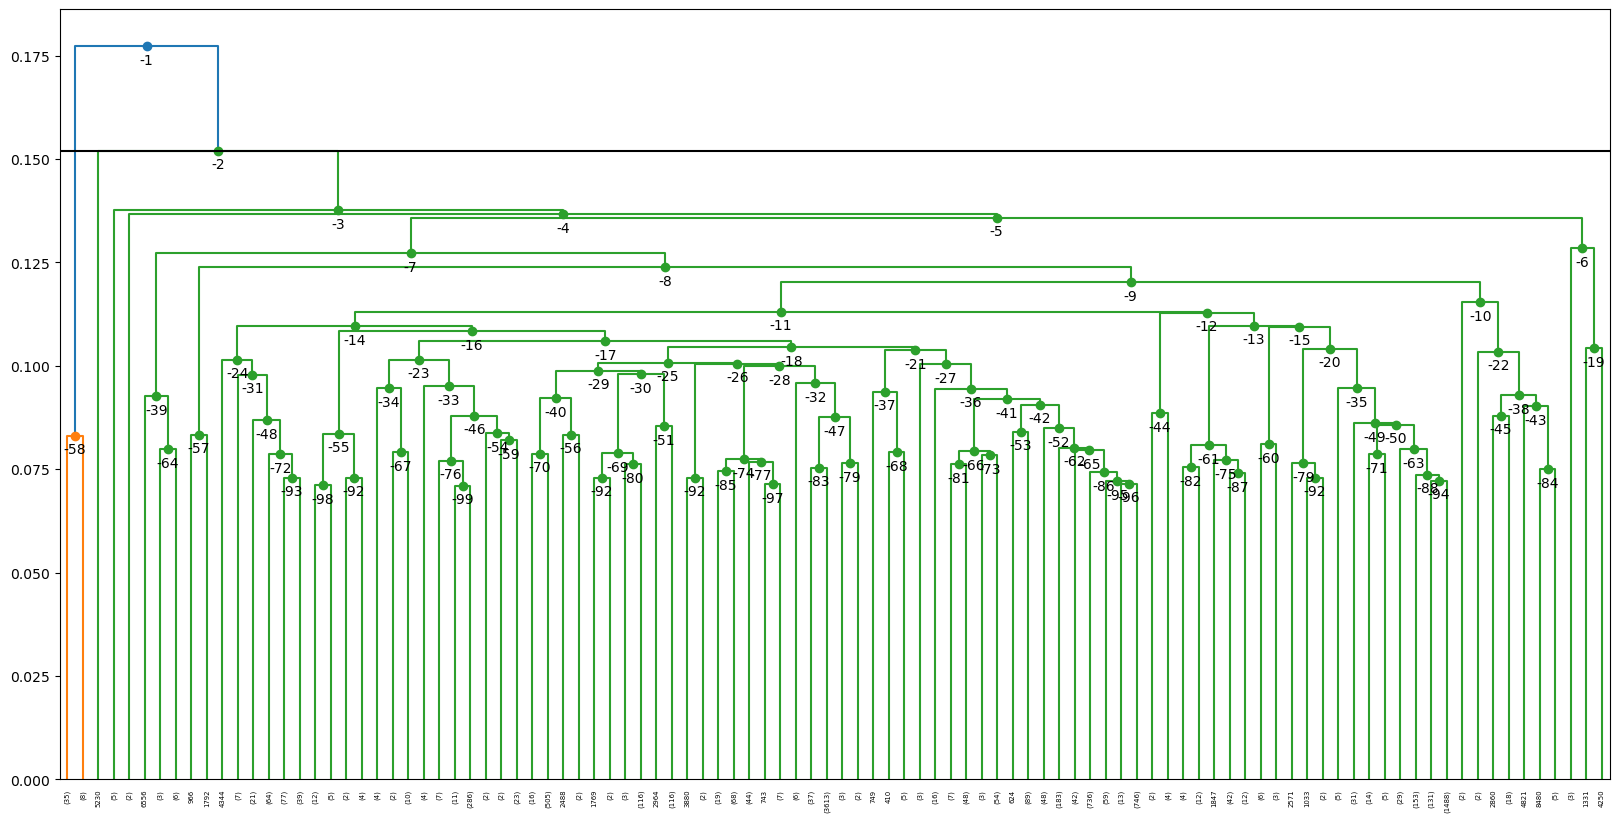

In [300]:
plot_dendrogram(model=agg_CAT, X=train_data[categorical_cols], truncate_mode='lastp', p=100, 
                n_clusters=2, 
                color_threshold=distance_threshold)

plt.show()

### NUM+PCA

In [301]:
hierarchical_cluster = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='average')
pred_labels_NUM_PCA_hierchical = hierarchical_cluster.fit_predict(X_pca_NUMfinal)

results_hierarchical_NUM_PCA = evaluate_clustering(pred_labels_NUM_PCA_hierchical, y, name="Hierarchical (Numerical, PCA)", X=X_pca_NUMfinal)

--- Hierarchical (Numerical, PCA) ---
Cluster sizes: cluster 0 = 3, cluster 1 = 9245
Accuracy (aligned): 0.8439  (labels swapped)
Purity: cluster 0 = 0.8441, cluster 1 = 1.0000
Jaccard: 0.0000 | ARI: -0.0005 | NMI: 0.0003
Silhouette: 0.8266 | Davies-Bouldin: 0.4568 | Calinski-Harabasz: 137.16



(<Figure size 2000x1000 with 1 Axes>, <Axes: >)

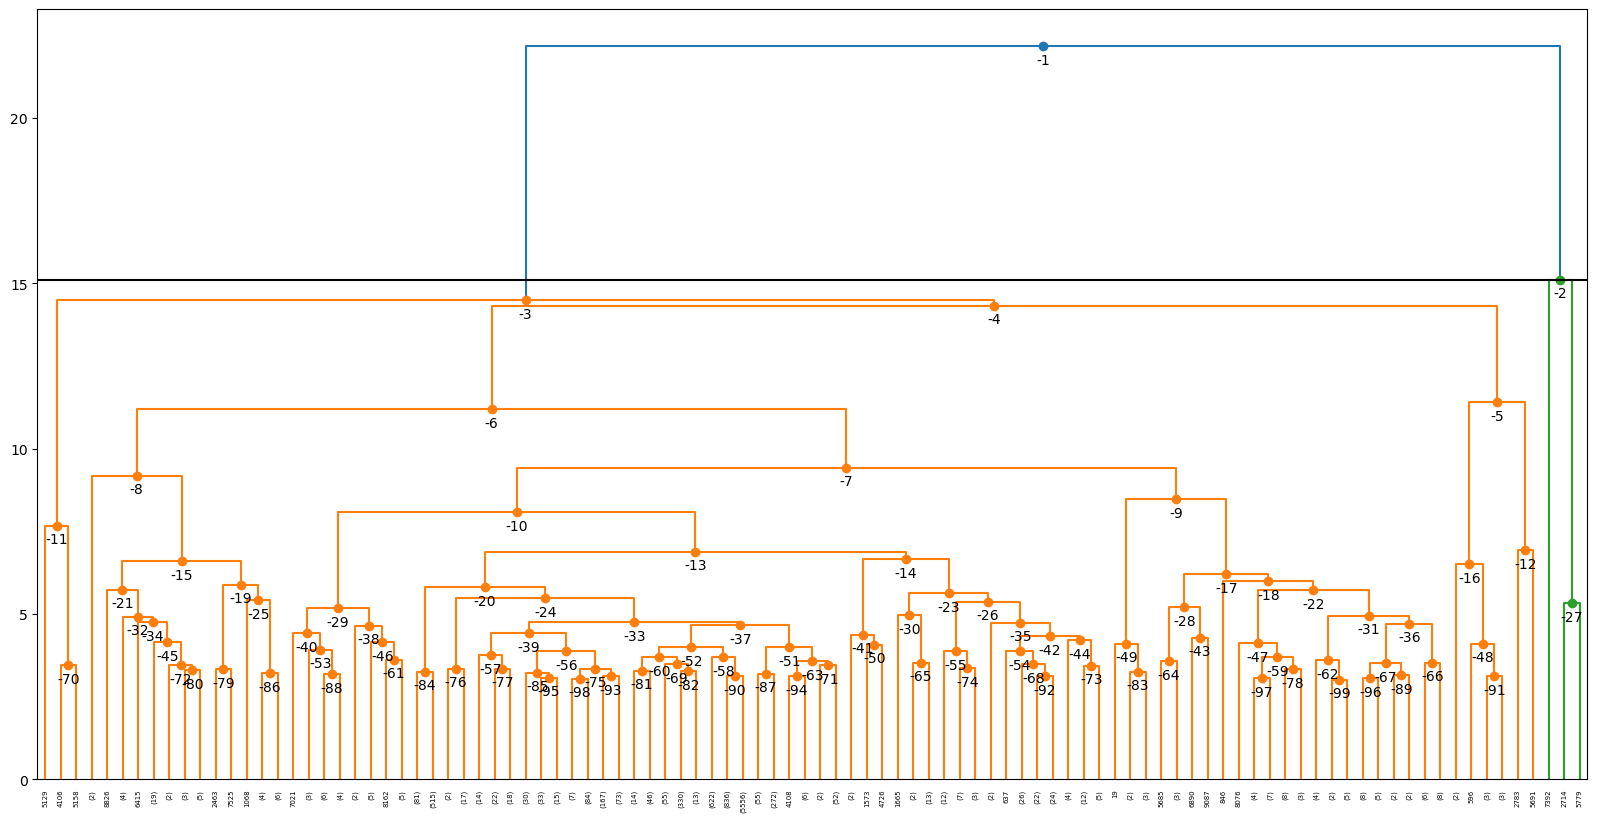

In [302]:
plot_dendrogram(model=hierarchical_cluster, X=X_NUMpca_array, truncate_mode='lastp', p=100, 
                n_clusters=2, 
                color_threshold=distance_threshold)

plt.show()

---

# FINAL CLUSTERING RESULTS

In [303]:
results_named = {
    "KMeans (Numerical)": results_kmeans_NUM,
    "KMeans (Numerical+PCA)": results_kmeans_NUM_PCA,
    "Hierchical (Numerical)": results_hierarchical_NUM,
    "Hierchical (Numerical+PCA)": results_hierarchical_NUM_PCA,
    "Hierchical (Categorical)": results_hierarchical_CAT,
    "Kmedoids (Numerical)": results_kmedoids_NUM,
    "Kmedoids (Numerical+PCA)": results_kmedoids_NUM_PCA,
    "Kmedoids (Categorical)": results_kmedoids_CAT,
}

all_results_df = pd.DataFrame(results_named).T

all_results_df

,Method,n_cluster_0,n_cluster_1,accuracy,recall_0_0,recall_0_1,recall_1_0,recall_1_1,precision_0_0,precision_0_1,precision_1_0,precision_1_1,purity_0,purity_1,jaccard,ari,nmi,silhouette,davies_bouldin,calinski_harabasz
KMeans (Numerical),"KMeans (Numerical, Scaled)",4406,4842,0.564338,0.524145,0.217904,0.475855,0.782096,0.928734,0.071266,0.767245,0.232755,0.928734,0.767245,0.21858,0.015465,0.046574,0.172492,2.063974,1569.599974
KMeans (Numerical+PCA),KMeans (6 PCA Components),4303,4945,0.562067,0.516203,0.189452,0.483797,0.810548,0.936556,0.063444,0.763802,0.236198,0.936556,0.763802,0.223841,0.0131,0.054118,0.203685,1.777986,1956.596179
Hierchical (Numerical),Hierarchical(Numerical),44,9204,0.843317,0.99667,0.987509,0.00333,0.012491,0.845393,0.154607,0.590909,0.409091,0.845393,0.590909,0.01227,0.012324,0.003809,0.885076,0.284287,3538.061775
Hierchical (Numerical+PCA),"Hierarchical (Numerical, PCA)",3,9245,0.843858,0.999616,1.0,0.000384,0.0,0.844132,0.155868,1.0,0.0,0.844132,1.0,0.0,-0.000528,0.000252,0.826559,0.456757,137.156689
Hierchical (Categorical),"Hierarchical(Categorical, Hamming)",9205,43,0.842128,0.996029,0.991672,0.003971,0.008328,0.844758,0.155242,0.72093,0.27907,0.844758,0.72093,0.008152,0.005853,0.000988,0.272357,0.912175,100.833562
Kmedoids (Numerical),"KMedoids (Numerical, Scaled)",4646,4602,0.546821,0.526323,0.342124,0.473677,0.657876,0.892873,0.107127,0.795954,0.204046,0.892873,0.795954,0.184472,0.008702,0.016097,0.19162,2.149724,1369.811285
Kmedoids (Numerical+PCA),"KMedoids (Numerical, Scaled)",4585,4663,0.560986,0.533624,0.29077,0.466376,0.70923,0.908615,0.091385,0.780828,0.219172,0.908615,0.780828,0.201102,0.014788,0.028329,0.228527,1.843332,1769.662561
Kmedoids (Categorical),"KMedoids (Numerical, Scaled)",4646,4602,0.546821,0.526323,0.342124,0.473677,0.657876,0.892873,0.107127,0.795954,0.204046,0.892873,0.795954,0.184472,0.008702,0.016097,0.006677,12.588294,56.361002


In [304]:
# Keep only internal + external columns
internal_cols = ['silhouette', 'davies_bouldin', 'calinski_harabasz']
external_cols = ['accuracy', 'jaccard', 'ari', 'nmi']

metric_df = all_results_df[internal_cols + external_cols]
metric_df



,silhouette,davies_bouldin,calinski_harabasz,accuracy,jaccard,ari,nmi
KMeans (Numerical),0.172492,2.063974,1569.599974,0.564338,0.21858,0.015465,0.046574
KMeans (Numerical+PCA),0.203685,1.777986,1956.596179,0.562067,0.223841,0.0131,0.054118
Hierchical (Numerical),0.885076,0.284287,3538.061775,0.843317,0.01227,0.012324,0.003809
Hierchical (Numerical+PCA),0.826559,0.456757,137.156689,0.843858,0.0,-0.000528,0.000252
Hierchical (Categorical),0.272357,0.912175,100.833562,0.842128,0.008152,0.005853,0.000988
Kmedoids (Numerical),0.19162,2.149724,1369.811285,0.546821,0.184472,0.008702,0.016097
Kmedoids (Numerical+PCA),0.228527,1.843332,1769.662561,0.560986,0.201102,0.014788,0.028329
Kmedoids (Categorical),0.006677,12.588294,56.361002,0.546821,0.184472,0.008702,0.016097


<Axes: >

Text(0.5, 1.0, 'External Agreement with Revenue by Clustering Method')

Text(0, 0.5, 'Score')

(array([0, 1, 2, 3, 4, 5, 6, 7]),
 [Text(0, 0, 'KMeans (Numerical)'),
  Text(1, 0, 'KMeans (Numerical+PCA)'),
  Text(2, 0, 'Hierchical (Numerical)'),
  Text(3, 0, 'Hierchical (Numerical+PCA)'),
  Text(4, 0, 'Hierchical (Categorical)'),
  Text(5, 0, 'Kmedoids (Numerical)'),
  Text(6, 0, 'Kmedoids (Numerical+PCA)'),
  Text(7, 0, 'Kmedoids (Categorical)')])

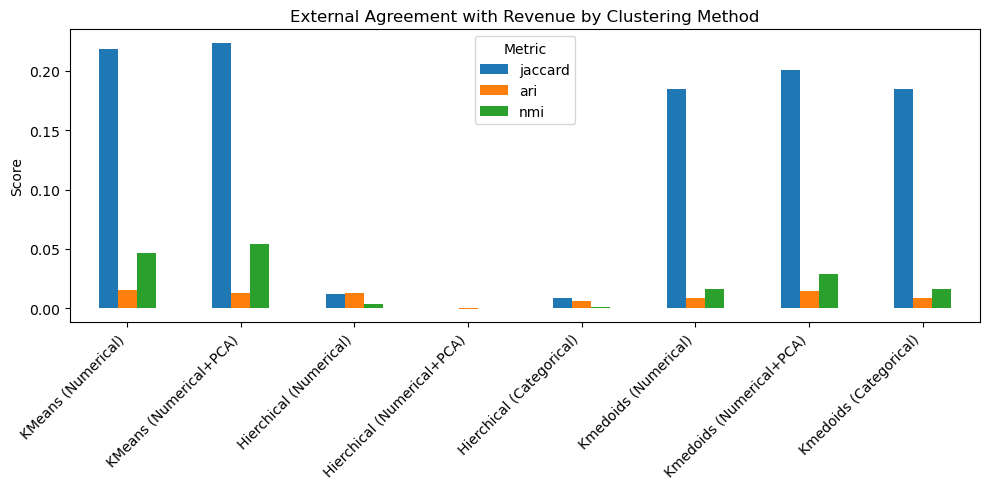

In [305]:
metrics_to_plot = ['jaccard', 'ari', 'nmi']
all_results_df[metrics_to_plot].plot(kind='bar', figsize=(10,5))
plt.title('External Agreement with Revenue by Clustering Method')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

Text(5, 5, 'KMeans (Numerical)')

Text(5, 5, 'KMeans (Numerical+PCA)')

Text(5, 5, 'Hierchical (Numerical)')

Text(5, 5, 'Hierchical (Numerical+PCA)')

...

Text(5, 5, 'Kmedoids (Numerical+PCA)')

Text(5, 5, 'Kmedoids (Categorical)')

Text(0.5, 0, 'Silhouette Score (internal quality)')

Text(0, 0.5, 'Jaccard Index (agreement with Revenue)')

Text(0.5, 1.0, 'Internal Quality vs External Alignment')

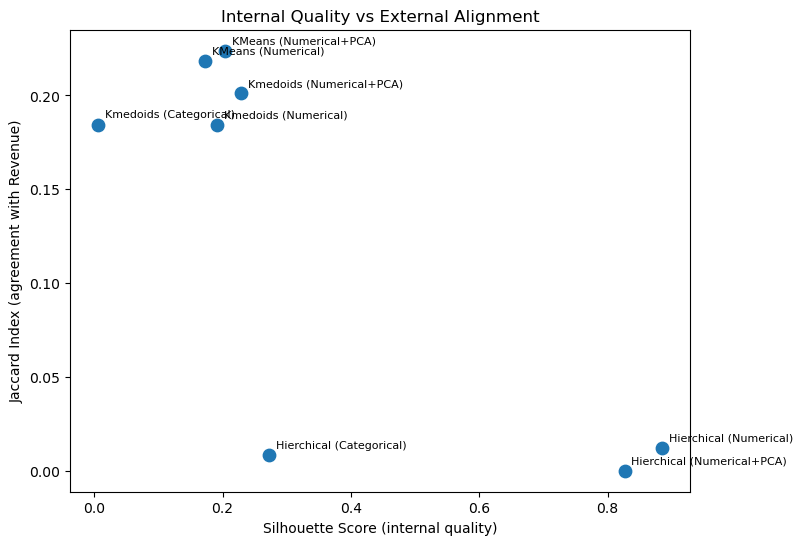

In [306]:
plt.figure(figsize=(8,6))
plt.scatter(all_results_df['silhouette'], all_results_df['jaccard'], s=80)

for method in all_results_df.index:
    plt.annotate(method, (all_results_df.loc[method, 'silhouette'], all_results_df.loc[method, 'jaccard']),
                 fontsize=8, xytext=(5,5), textcoords='offset points')

plt.xlabel('Silhouette Score (internal quality)')
plt.ylabel('Jaccard Index (agreement with Revenue)')
plt.title('Internal Quality vs External Alignment')
plt.show()

We select K-Means (Numerical+PCA) as our best clustering method based on Jaccard Index (0.223)

Among all clustering configurations tested, K-Means (Numerical+PCA) achieves the best alignment with the true
Revenue labels (Jaccard = 0.224, NMI = 0.054), and is comparable to the best ARI scores in the table (0.013,
close to the top values of 0.015 for K-Means (Numerical) and 0.015 for K-Medoids (Numerical+PCA)). This is
despite NOT having the highest internal cluster quality — Hierarchical clustering achieves dramatically higher
silhouette scores (up to 0.885), yet its Jaccard/ARI/NMI are near zero, indicating it identifies a compact,
well-separated structure in the data that is unrelated to purchasing behavior. Hierarchical's high reported
accuracy (~0.84) is likewise misleading, reflecting the ~84% majority-class baseline rather than genuine
predictive skill, since both Jaccard and ARI are close to zero. We therefore select K-Means (Numerical+PCA) as
our representative clustering-based approach for the final comparison against our best supervised classifier.

## Best classifier vs Best clustering method

We have observed that the best clustering method performs best with numerical features + PCA dimensionality reduction. Let us now see how the best classifier performs with NUM_PCA.
We will train the best classifer on the training dataset and then compare the performance with the test set

In [307]:
#we will fit the logistic regression with the same variable that was used to the best clustring method in order to compare the two models:
#target variable:
y_train=train_data['Revenue'].astype(int)
y_test=test_data['Revenue'].astype(int)

#selecting the number of components as before:
pca = PCA(n_components=6)

#scaling for train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_data[numerical_cols])
X_train_pca = pca.fit_transform(X_train_scaled)

X_test_scaled = scaler.transform(test_data[numerical_cols])   # note: transform, not fit_transform
X_test_pca = pca.transform(X_test_scaled)  

In [308]:
#logistic regression fitting:
classifier = LogisticRegression(max_iter=1000, class_weight='balanced')
classifier.fit(X_train_pca, y_train)

#prediction:
y_pred_lr = classifier.predict(X_test_pca)

y_proba_lr = classifier.predict_proba(X_test_pca)[:, 1]

LogisticRegression(class_weight='balanced', max_iter=1000)

In [309]:
#evaluation for logistic regression:
lr_results = {
    'Method': 'Logistic Regression (Supervised)',
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'precision': precision_score(y_test, y_pred_lr),
    'recall': recall_score(y_test, y_pred_lr),
    'f1': f1_score(y_test, y_pred_lr),
    'roc_auc': roc_auc_score(y_test, y_proba_lr)
}
print(lr_results)
lr_results

len(pred_labels_NUM_PCAmedoids)

{'Method': 'Logistic Regression (Supervised)', 'accuracy': 0.881245944192083, 'precision': 0.5802861685214626, 'recall': 0.7815845824411135, 'f1': 0.666058394160584, 'roc_auc': np.float64(0.9130956718978386)}


{'Method': 'Logistic Regression (Supervised)',
 'accuracy': 0.881245944192083,
 'precision': 0.5802861685214626,
 'recall': 0.7815845824411135,
 'f1': 0.666058394160584,
 'roc_auc': np.float64(0.9130956718978386)}

9248

In [310]:
#best clusering method evaluation:

#Since clustering is an unsupervised learning technique and does not directly produce class predictions, we defined a function that assigns a class label to each cluster according 
# to the majority class of its training samples. This mapping enables the evaluation of the clustering algorithm as a classifier.
def clusters_to_predictions(cluster_labels, y_true):
    cluster_to_class = {}
    cluster_to_prob = {}
    for c in np.unique(cluster_labels):
        mask = cluster_labels == c
        cluster_to_class[c] = pd.Series(y_true[mask]).mode()[0]
        cluster_to_prob[c] = pd.Series(y_true[mask]).mean() 
    predictions = np.array([cluster_to_class[c] for c in cluster_labels])
    probabilities = np.array([cluster_to_prob[c] for c in cluster_labels])
    return predictions, probabilities, cluster_to_class

# pred_labels_NUM_PCA_medoids = your K-Medoids cluster assignments on training data (NUM + PCA)
y_pred_kmeans, y_proba_kmeans, mapping = clusters_to_predictions(pred_labels_NUM_PCA_kmeans, y)
print("Cluster -> class mapping:", mapping)

Cluster -> class mapping: {np.int32(0): np.int64(0), np.int32(1): np.int64(0)}


In [311]:
test_clusters_km = kmeans_NUM_PCA.predict(X_test_pca)  # assign test points to existing clusters

y_pred_kmeans_test = np.array([mapping[c] for c in test_clusters_km])


cluster_probs = {}
for c in np.unique(pred_labels_NUM_PCA_kmeans):
    mask = pred_labels_NUM_PCA_kmeans == c
    cluster_probs[c] = pd.Series(y)[mask].mean()

y_proba_kmeans_test = np.array([cluster_probs[c] for c in test_clusters_km])

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [312]:
#summarizing the results:
kmeans_results = {
    'Method': 'K-Means (NUM + PCA) as Classifier',
    'accuracy': accuracy_score(y_test, y_pred_kmeans_test),
    'precision': precision_score(y_test, y_pred_kmeans_test),
    'recall': recall_score(y_test, y_pred_kmeans_test),
    'f1': f1_score(y_test, y_pred_kmeans_test),
    'roc_auc': roc_auc_score(y_test, y_pred_kmeans_test)
}

kmeans_results

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'Method': 'K-Means (NUM + PCA) as Classifier',
 'accuracy': 0.8484750162232316,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': np.float64(0.5)}

Text(0.5, 1.0, 'K-Means Clusters (PC1 vs PC2)')

Text(0.5, 0, 'PC1')

Text(0, 0.5, 'PC2')

Text(0.5, 1.0, 'True Revenue Labels (PC1 vs PC2)')

Text(0.5, 0, 'PC1')

Text(0, 0.5, 'PC2')

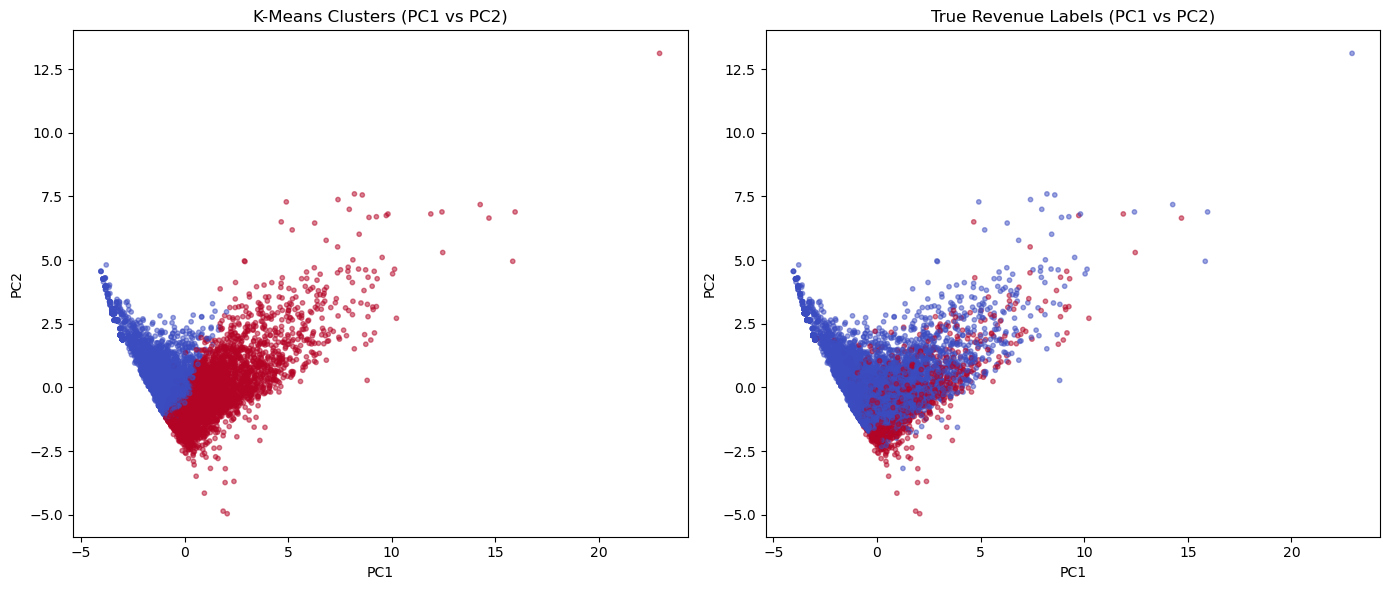

In [313]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: colored by predicted cluster
axes[0].scatter(X_NUMpca_array[:,0], X_NUMpca_array[:,1], c=pred_labels_NUM_PCA_kmeans, cmap='coolwarm', alpha=0.5, s=10)
axes[0].set_title('K-Means Clusters (PC1 vs PC2)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# Right: colored by TRUE Revenue label
axes[1].scatter(X_NUMpca_array[:,0], X_NUMpca_array[:,1], c=y, cmap='coolwarm', alpha=0.5, s=10)
axes[1].set_title('True Revenue Labels (PC1 vs PC2)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

The K-Means clustering produces two well-separated groups that follow the direction of maximum variance in the numerical features (PC1), but this partition does not align with the true Revenue labels, which appear scattered across both clusters without forming a distinct region. This suggests that the geometric structure captured by PCA is not predictive of purchasing behavior, likely because Revenue depends on a more complex combination of factors, including categorical variables not included in this PCA. As a result, low agreement is expected between the unsupervised clusters and the ground truth (e.g., low ARI/NMI scores).

In [314]:
comparison_df = pd.DataFrame([kmeans_results, lr_results])
comparison_df = comparison_df.set_index('Method')
comparison_df

,accuracy,precision,recall,f1,roc_auc
Method,,,,,
K-Means (NUM + PCA) as Classifier,0.848475,0.000000,0.000000,0.000000,0.500000
Logistic Regression (Supervised),0.881246,0.580286,0.781585,0.666058,0.913096


<BarContainer object of 5 artists>

<BarContainer object of 5 artists>

[Text(0, 0, 'accuracy'),
 Text(1, 0, 'precision'),
 Text(2, 0, 'recall'),
 Text(3, 0, 'f1'),
 Text(4, 0, 'roc_auc')]

Text(0, 0.5, 'Score')

(0.0, 1.0)

Text(0.5, 1.0, 'Metrics comparison: K-Means(NUM+PCA) vs Logistic Regression')

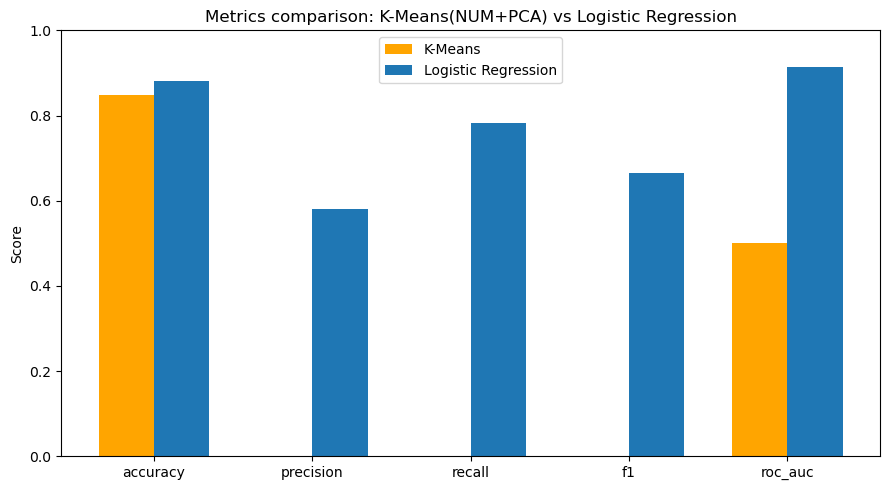

In [315]:
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, comparison_df.loc['K-Means (NUM + PCA) as Classifier', metrics], width, label='K-Means', color='orange')
ax.bar(x + width/2, comparison_df.loc['Logistic Regression (Supervised)', metrics], width, label='Logistic Regression', color='tab:blue')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Metrics comparison: K-Means(NUM+PCA) vs Logistic Regression')
ax.legend()
plt.tight_layout()
plt.show()

<Figure size 700x600 with 0 Axes>

Text(0.5, 0, 'False Positive Rate')

Text(0, 0.5, 'True Positive Rate')

Text(0.5, 1.0, 'ROC Curve: Best Classifier vs Best Clustering Method')

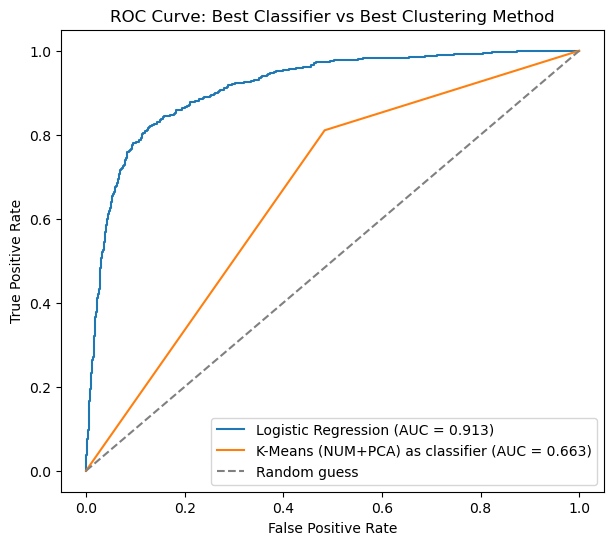

In [316]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Logistic Regression — evaluated on the test set
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)

# K-Means (NUM+PCA) as classifier — make sure y_proba_kmeans_test comes from TEST-set cluster assignments
fpr_km, tpr_km, _ = roc_curve(y, y_proba_kmeans)
auc_km = auc(fpr_km, tpr_km)

plt.figure(figsize=(7,6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', color='tab:blue')
plt.plot(fpr_km, tpr_km, label=f'K-Means (NUM+PCA) as classifier (AUC = {auc_km:.3f})', color='tab:orange')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Best Classifier vs Best Clustering Method')
plt.legend()
plt.show()

f1 score = 0 means that this model never predicted the positive class but high accuracy means that the model predicted all of the negative classes. This is due to the imbalance between the two classes (Revenue true and false). 

As a final consideration, when using only the numerical variables, Logistic Regression clearly outperformed K-Means across all evaluation metrics. This indicates that, for this dataset, predicting Revenue is better addressed as a supervised classification task rather than an unsupervised clustering one. Specifically, the Logistic Regression model built on the features selected in Task 2 provides the best overall performance summary, and is therefore the recommended approach for this prediction task

---
---
---

# CONCLUSION

## Summary

*Task 1 — Regression (Exit Rate recovery):* We compared several regressors via cross-validation to predict 
the missing Exit Rate values from training data, selecting Random Forest as the best-performing model. We used 
it to impute Exit Rate in both the training and test sets.

*Task 2 — Classification (Revenue prediction):* We compared multiple classifiers (Logistic Regression, LDA, 
QDA, SVM, KNN variants) and selected Logistic Regression as our best model, using Lasso 
(L1-regularized Logistic Regression) as our exclusive feature selection method. We found that including the recovered Exit Rate feature 
made virtually no difference to classification performance (~0.01 difference in F1/accuracy), and slightly 
favored excluding it, so our final model does not rely on Exit Rate.

*Task 3 — Clustering-based classification:* We explored several clustering algorithms (K-Means, K-Medoids, 
Hierarchical) across different feature representations, converting cluster assignments into Revenue 
predictions via majority vote. K-Means on PCA-reduced numerical features gave the best alignment with the true 
labels among clustering approaches, but — as expected — it performed substantially worse than our supervised 
Logistic Regression model, since clustering is not optimized to separate buyers from non-buyers directly. This 
confirms that supervised classification remains the superior approach for this task, though clustering did 
capture some weak, genuine signal related to purchasing behavior.

Overall, purchasing intent seems to be driven by a relatively small set of behavioral features, and supervised 
learning clearly beats the unsupervised approach here, which makes sense given clustering never sees the 
target during training.

---
---
---